# 1.Package Import

In [73]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature

import pickle

In [74]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Global file location (need to specify your own path)

In [75]:
NWB_DIR="C:\\Users\\cierr\\OneDrive\\Documents\\bmovie\\nwb_files"
BIDS_DIR="C:\\Users\\cierr\\OneDrive\\Documents\\bmovie\\bids_files"

In [76]:
# gen_table1_subj_info.main(
#     nwb_input_dir=NWB_DIR,
#     bids_datadir=BIDS_DIR
# )

In [77]:
# nwb_df, bids_df = data_summary.run_summary(NWB_DIR, BIDS_DIR, max_nwb_files=3, max_bids_files_each=5)

# nwb_df.head(), bids_df.head()

# 3. Load labels and data

In [78]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [79]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

In [80]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: C:\Users\cierr\OneDrive\Documents\bmovie\nwb_files\000623\sub-CS41\sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [81]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
from pynwb import NWBHDF5IO

# fMRI (optional)
from bids import BIDSLayout
import nibabel as nib
import traceback

# signal processing
from scipy.signal import butter, sosfiltfilt, hilbert
from collections.abc import Iterable

# -----------------------
# Subject mapping (int -> ids)
# -----------------------
def bids_subject_from_int(sub: int) -> str:
    return f"p{sub}cs"   # BIDS folder: sub-p41cs


def nwb_subject_from_int(sub: int) -> str:
    return f"CS{sub}"    # NWB subject: sub-CS41


# -----------------------
# Path finding
# -----------------------
def find_nwb_file_for_subject(nwb_root: Union[str, Path], nwb_sub: str) -> Path:
    nwb_root = Path(nwb_root)
    if not nwb_root.exists():
        raise FileNotFoundError(f"NWB root not found: {nwb_root}")

    patterns = [
        f"**/sub-{nwb_sub}/*.nwb",
        f"**/sub-{nwb_sub}*.nwb",
        f"**/*sub-{nwb_sub}*.nwb",
    ]
    hits: List[Path] = []
    for pat in patterns:
        hits.extend(nwb_root.glob(pat))
    hits = sorted(set(hits))

    if not hits:
        all_nwb = list(nwb_root.rglob("*.nwb"))
        hits = sorted([p for p in all_nwb if f"sub-{nwb_sub}" in str(p)])

    if not hits:
        raise FileNotFoundError(f"No NWB found for subject {nwb_sub} under {nwb_root}")

    return hits[0]


# -----------------------
# Time utilities
# -----------------------
def times_from_rate(T: int, rate: float, starting_time: float = 0.0) -> np.ndarray:
    # t[i] = starting_time + i/rate
    return starting_time + np.arange(T, dtype=np.float64) / float(rate)


def get_ts_data_and_time(ts, max_samples: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray, Optional[float]]:
    """
    Return (data, t, rate) for an NWB TimeSeries-like object.
    Tries timestamps first, otherwise uses (starting_time, rate).
    """
    if max_samples is None:
        data = np.asarray(ts.data[:])
    else:
        data = np.asarray(ts.data[:max_samples])

    rate = getattr(ts, "rate", None)
    starting_time = getattr(ts, "starting_time", 0.0)

    # timestamps can be large; only load if present
    if getattr(ts, "timestamps", None) is not None:
        if max_samples is None:
            t = np.asarray(ts.timestamps[:], dtype=np.float64)
        else:
            t = np.asarray(ts.timestamps[:max_samples], dtype=np.float64)
    else:
        if rate is None:
            raise ValueError("TimeSeries has no timestamps and no rate; cannot build time axis.")
        t = times_from_rate(len(data), rate, float(starting_time))

    return data, t, rate


def resample_continuous(x: np.ndarray, t_src: np.ndarray, t_dst: np.ndarray) -> np.ndarray:
    """
    x: (T,) or (T,C). Linear interpolation onto t_dst.
    """
    if x.ndim == 1:
        return np.interp(t_dst, t_src, x).astype(np.float32)
    elif x.ndim == 2:
        out = np.empty((len(t_dst), x.shape[1]), dtype=np.float32)
        for c in range(x.shape[1]):
            out[:, c] = np.interp(t_dst, t_src, x[:, c])
        return out
    else:
        raise ValueError(f"resample_continuous expects 1D or 2D, got {x.ndim}D")

def _pick_first_series(container, prefer: Optional[List[str]] = None) -> str:
    """
    container: a MultiContainerInterface-like object with .keys() and __getitem__ expecting str
    prefer: optional list of preferred key substrings (case-insensitive)
    Returns: a key string that works with container[key]
    """
    keys_raw = list(container.keys())
    keys_str = [k if isinstance(k, str) else str(k) for k in keys_raw]

    # optional preference ordering
    if prefer:
        prefer_l = [p.lower() for p in prefer]
        keys_str = sorted(
            keys_str,
            key=lambda s: 0 if any(p in s.lower() for p in prefer_l) else 1
        )

    last_err = None
    for k in keys_str:
        try:
            _ = container[k]   # probe
            return k
        except Exception as e:
            last_err = e
            continue

    raise TypeError(f"Could not index container with any stringified key. "
                    f"raw keys={keys_raw[:10]}... last_err={repr(last_err)}")

# -----------------------
# Spikes -> firing rate
# -----------------------
def spikes_to_firing_rate(spike_times_list: List[np.ndarray], t_grid: np.ndarray) -> np.ndarray:
    """
    Bin spikes into firing rate on t_grid (sec).
    We interpret t_grid as bin centers; derive bin edges from midpoints.
    Output shape: (T, n_units) in Hz.
    """
    T = len(t_grid)
    n_units = len(spike_times_list)
    if T < 2:
        raise ValueError("t_grid must have at least 2 points.")

    # bin edges from centers
    dt = np.median(np.diff(t_grid))
    edges = np.concatenate(([t_grid[0] - dt/2], t_grid + dt/2))
    fr = np.zeros((T, n_units), dtype=np.float32)

    for i, st in enumerate(spike_times_list):
        if st is None or len(st) == 0:
            continue
        counts, _ = np.histogram(st, bins=edges)
        fr[:, i] = counts.astype(np.float32) / float(dt)  # Hz
    return fr


# -----------------------
# LFP band power
# -----------------------
def bandpower_hilbert(
    lfp: np.ndarray,
    fs: float,
    band: Tuple[float, float],
) -> np.ndarray:
    """
    lfp: (T,C) or (T,)
    Returns power envelope (T,C) or (T,) using bandpass + Hilbert magnitude^2.
    """
    lo, hi = band
    if fs is None:
        raise ValueError("fs required for bandpower.")

    sos = butter(4, [lo, hi], btype="bandpass", fs=float(fs), output="sos")
    if lfp.ndim == 1:
        y = sosfiltfilt(sos, lfp)
        env = np.abs(hilbert(y)) ** 2
        return env.astype(np.float32)
    elif lfp.ndim == 2:
        out = np.empty_like(lfp, dtype=np.float32)
        for c in range(lfp.shape[1]):
            y = sosfiltfilt(sos, lfp[:, c])
            out[:, c] = (np.abs(hilbert(y)) ** 2).astype(np.float32)
        return out
    else:
        raise ValueError("lfp must be 1D or 2D")


# -----------------------
# NWB modality loaders
# -----------------------
def load_lfp_container(nwbfile, which: str, max_samples: Optional[int] = None):
    ece = nwbfile.processing["ecephys"]
    if hasattr(ece, "data_interfaces") and which in ece.data_interfaces:
        lfp_interface = ece.data_interfaces[which]
    else:
        lfp_interface = ece[which]

    series_key = _pick_first_series(
        lfp_interface.electrical_series,
        prefer=["ElectricalSeries", "LFP"]
    )
    ts = lfp_interface.electrical_series[series_key]

    lfp, t, fs = get_ts_data_and_time(ts, max_samples=max_samples)
    lfp = np.asarray(lfp)
    if lfp.ndim == 1:
        lfp = lfp[:, None]
    return lfp.astype(np.float32), np.asarray(t, dtype=np.float64), fs


def load_eye_gaze_and_pupil(nwbfile, max_samples: Optional[int] = None):
    beh = nwbfile.processing["behavior"]

    gaze = None
    pupil = None
    t_eye = None

    # IMPORTANT: do NOT use `if "EyeTracking" in beh` (can trigger bad __contains__)
    beh_keys_raw = list(beh.keys())
    beh_keys_str = {k if isinstance(k, str) else str(k) for k in beh_keys_raw}

    if "EyeTracking" in beh_keys_str:
        et = beh["EyeTracking"]  # now safe, we only index with str
        key = _pick_first_series(et.spatial_series, prefer=["SpatialSeries", "gaze"])
        ts = et.spatial_series[key]
        data, t, _ = get_ts_data_and_time(ts, max_samples=max_samples)
        gaze = np.asarray(data).astype(np.float32)
        t_eye = np.asarray(t, dtype=np.float64)

    if "PupilTracking" in beh_keys_str:
        pt = beh["PupilTracking"]
        key = _pick_first_series(pt.time_series, prefer=["TimeSeries", "pupil"])
        ts = pt.time_series[key]
        data, t, _ = get_ts_data_and_time(ts, max_samples=max_samples)
        pupil = np.asarray(data).squeeze().astype(np.float32)
        if t_eye is None:
            t_eye = np.asarray(t, dtype=np.float64)

    return gaze, pupil, t_eye


def load_spikes_units(nwbfile) -> List[np.ndarray]:
    """
    Return list of spike_times arrays (seconds), one per unit.
    """
    if getattr(nwbfile, "units", None) is None:
        return []
    df = nwbfile.units.to_dataframe()
    if "spike_times" not in df.columns:
        return []
    spikes = []
    for st in df["spike_times"].values:
        # st is typically an array-like of spike times
        spikes.append(np.asarray(st, dtype=np.float64))
    return spikes


def load_movie_time(nwbfile, max_samples: Optional[int] = None) -> np.ndarray:
    """
    Use stimulus['movieframe_time'] as the common time grid (seconds).
    """
    stim = nwbfile.stimulus
    if "movieframe_time" not in stim:
        raise KeyError("movieframe_time not found in nwbfile.stimulus")
    ts = stim["movieframe_time"]
    data, _, _ = get_ts_data_and_time(ts, max_samples=max_samples)
    data = np.asarray(data).squeeze().astype(np.float64)
    return data


# -----------------------
# fMRI optional extraction
# -----------------------
def load_bold_timeseries_wholebrain(bids_root: Union[str, Path], bids_sub: str, max_runs: Optional[int] = None) -> List[np.ndarray]:
    """
    Returns list of arrays (T,V). Uses nilearn NiftiMasker.
    """
    from nilearn.maskers import NiftiMasker

    layout = BIDSLayout(str(bids_root), validate=False)
    bold_files: List[str] = layout.get(subject=bids_sub, datatype="func", suffix="bold",
                                       extension=["nii", "nii.gz"], return_type="file")
    if max_runs is not None:
        bold_files = bold_files[:max_runs]

    masker = NiftiMasker(standardize=False)
    out = []
    for f in bold_files:
        img = nib.load(f)
        X = masker.fit_transform(img)  # (T,V)
        out.append(X.astype(np.float32))
    return out


# -----------------------
# Main multimodal loader
# -----------------------
def load_multimodal_subjects(
    sub_nums: Union[Iterable[int], set],
    nwb_root: Union[str, Path],
    bids_root: Union[str, Path],
    *,
    max_nwb_samples: Optional[int] = None,
    resample_lfp: bool = False,
    use_movie_time_as_grid: bool = True,
    grid_dt: Optional[float] = None,
    compute_firing_rate: bool = True,
    compute_lfp_bandpower: bool = True,
    bands: Optional[Dict[str, Tuple[float, float]]] = None,
    load_fmri: bool = False,
    fmri_max_runs: Optional[int] = None,
    verbose: bool = True,
    **kwargs,   # <-- 兼容多余参数，避免 TypeError
) -> Dict[int, Dict[str, Any]]:

    if kwargs and verbose:
        print(f"[WARN] load_multimodal_subjects ignored kwargs: {sorted(kwargs.keys())}")

    if bands is None:
        bands = {
            "theta": (4, 8),
            "alpha": (8, 12),
            "beta": (13, 30),
            "gamma": (30, 80),
            "high_gamma": (80, 150),
        }

    out: Dict[int, Dict[str, Any]] = {}

    for sub in sub_nums:
        if not isinstance(sub, int):
            raise TypeError(f"sub_nums must contain int, got {sub} ({type(sub)})")

        bids_sub = bids_subject_from_int(sub)
        nwb_sub = nwb_subject_from_int(sub)

        nwb_path = None
        io = None

        try:
            nwb_path = find_nwb_file_for_subject(nwb_root, nwb_sub)

            io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
            nwbfile = io.read()

            # -----------------------------
            # 1) 先读 LFP（拿到原始时间轴）
            # -----------------------------
            lfp_macro, t_macro, fs_macro = load_lfp_container(
                nwbfile, "LFP_macro", max_samples=max_nwb_samples
            )
            lfp_micro, t_micro, fs_micro = load_lfp_container(
                nwbfile, "LFP_micro", max_samples=max_nwb_samples
            )

            if verbose:
                print(f"[sub {sub}] nwb_path={nwb_path}")
                print(f"[sub {sub}] lfp_macro shape={lfp_macro.shape} dtype={lfp_macro.dtype}")
                print(f"[sub {sub}] t_macro len={len(t_macro)} range=({t_macro[0]:.3f}, {t_macro[-1]:.3f}) fs={fs_macro}")
                print(f"[sub {sub}] lfp_macro min/max=({float(np.min(lfp_macro)):.3f}, {float(np.max(lfp_macro)):.3f})")

            # -----------------------------
            # 2) 决定公共时间网格 t_grid
            #    - 你现在要“先观测原始数据”
            #    - resample_lfp=False => t_grid = t_macro（完整 LFP 采样）
            # -----------------------------
            movie_time = None
            movie_time_error = None

            if not resample_lfp:
                t_grid = t_macro
            else:
                if use_movie_time_as_grid:
                    # 用 movie frame time 作为网格（会很稀疏，仅在你明确要这样时用）
                    t_grid = load_movie_time(nwbfile, max_samples=max_nwb_samples)
                else:
                    if grid_dt is None:
                        raise ValueError("If use_movie_time_as_grid=False you must provide grid_dt.")
                    t0, t1 = float(t_macro[0]), float(t_macro[-1])
                    t_grid = np.arange(t0, t1, float(grid_dt), dtype=np.float64)

            # movie_time 单独读出来（用于对齐/标注事件），不再用于强制重采样
            if use_movie_time_as_grid:
                try:
                    movie_time = load_movie_time(nwbfile, max_samples=max_nwb_samples)
                except Exception as e:
                    movie_time_error = repr(e)
                    movie_time = None

            if verbose:
                print(f"[sub {sub}] resample_lfp={resample_lfp} -> t_grid len={len(t_grid)} "
                      f"(expect == len(t_macro) when resample_lfp=False)")
                if movie_time is not None:
                    print(f"[sub {sub}] movie_time len={len(movie_time)} range=({movie_time[0]:.3f}, {movie_time[-1]:.3f})")
                else:
                    print(f"[sub {sub}] movie_time=None ({movie_time_error})")

            # -----------------------------
            # 3) LFP 是否重采样
            # -----------------------------
            if resample_lfp:
                lfp_macro_rs = resample_continuous(lfp_macro, t_macro, t_grid)
                lfp_micro_rs = resample_continuous(lfp_micro, t_micro, t_grid)
            else:
                lfp_macro_rs = lfp_macro
                lfp_micro_rs = lfp_micro

            # -----------------------------
            # 4) Eye + pupil（如果你只看 LFP，可之后再关掉）
            # -----------------------------
            gaze, pupil, t_eye = load_eye_gaze_and_pupil(nwbfile, max_samples=max_nwb_samples)

            gaze_rs = None
            if gaze is not None and t_eye is not None:
                gaze_rs = resample_continuous(gaze, t_eye, t_grid)
                if gaze_rs.ndim == 2 and gaze_rs.shape[1] >= 2:
                    gaze_rs = gaze_rs[:, :2]

            pupil_rs = None
            if pupil is not None and t_eye is not None:
                pupil_rs = resample_continuous(pupil, t_eye, t_grid).astype(np.float32).squeeze()

            # -----------------------------
            # 5) Spikes -> firing rate（t_grid 很密时会很稀疏，但能跑）
            # -----------------------------
            spikes_list = load_spikes_units(nwbfile)
            firing_rate = spikes_to_firing_rate(spikes_list, t_grid) if compute_firing_rate else None

            # -----------------------------
            # 6) LFP band power（注意：如果你 resample 且 grid_dt 改了，fs 也要跟着变）
            # -----------------------------
            lfp_bandpower: Dict[str, np.ndarray] = {}
            if compute_lfp_bandpower:
                fs_for_bp = fs_macro if (not resample_lfp or grid_dt is None) else (1.0 / float(grid_dt))
                for name, band in bands.items():
                    lfp_bandpower[name] = bandpower_hilbert(lfp_macro_rs, fs=fs_for_bp, band=band)

            # -----------------------------
            # 7) fMRI（可选）
            # -----------------------------
            bold_list: List[np.ndarray] = []
            fmri_error = None
            if load_fmri:
                try:
                    bold_list = load_bold_timeseries_wholebrain(bids_root, bids_sub, max_runs=fmri_max_runs)
                except Exception as e:
                    fmri_error = repr(e)
                    bold_list = []

            # -----------------------------
            # 8) 输出
            # -----------------------------
            out[sub] = {
                "spikes": spikes_list,
                "firing_rate": firing_rate,
                "lfp_macro": lfp_macro_rs,
                "lfp_micro": lfp_micro_rs,
                "lfp_bandpower": lfp_bandpower,
                "eye_gaze": gaze_rs,
                "pupil": pupil_rs,
                "time_grid": np.asarray(t_grid, dtype=np.float64),  # <-- 真实公共时间轴
                "movie_time": None if movie_time is None else np.asarray(movie_time, dtype=np.float64),
                "bold": bold_list,
                "meta": {
                    "sub": sub,
                    "bids_sub": bids_sub,
                    "nwb_sub": nwb_sub,
                    "nwb_path": str(nwb_path),
                    "fs_macro": fs_macro,
                    "fs_micro": fs_micro,
                    "n_units": len(spikes_list),
                    "fmri_error": fmri_error,
                    "movie_time_error": movie_time_error,
                    "resample_lfp": resample_lfp,
                    "max_nwb_samples": max_nwb_samples,
                },
            }

        except Exception as e:
            out[sub] = {
                "meta": {
                    "sub": sub,
                    "bids_sub": bids_sub,
                    "nwb_sub": nwb_sub,
                    "nwb_path": str(nwb_path) if nwb_path else None,
                    "error": repr(e),
                    "traceback": traceback.format_exc(),
                }
            }

        finally:
            if io is not None:
                io.close()

    return out

In [82]:
sub_nums = [41]
data = load_data_into_dict.load_multimodal_subjects(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=100_000,
    load_fmri=False,
    resample_lfp=False,
)

[sub 41] nwb_path=C:\Users\cierr\OneDrive\Documents\bmovie\nwb_files\000623\sub-CS41\sub-CS41_ses-P41CSR1_behavior+ecephys.nwb
[sub 41] lfp_macro shape=(100000, 96) dtype=float32
[sub 41] t_macro len=100000 range=(0.000, 99.999) fs=1000.0
[sub 41] lfp_macro min/max=(-0.001, 0.001)
[sub 41] resample_lfp=False -> t_grid len=100000 (expect == len(t_macro) when resample_lfp=False)
[sub 41] movie_time len=11971 range=(0.000, 11970.000)


In [83]:
eye_data = data[sub_nums[0]]["eye_gaze"]
print("movie_time shape:", data[sub_nums[0]]["movie_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print(eye_data[:5])

movie_time shape: (11971,)
eye_gaze shape: (100000, 2)
[[630.2285 548.    ]
 [630.7285 548.    ]
 [631.     548.    ]
 [631.     548.    ]
 [631.2285 548.    ]]


Text(0.5, 1.0, 'PCA Explained Variance')

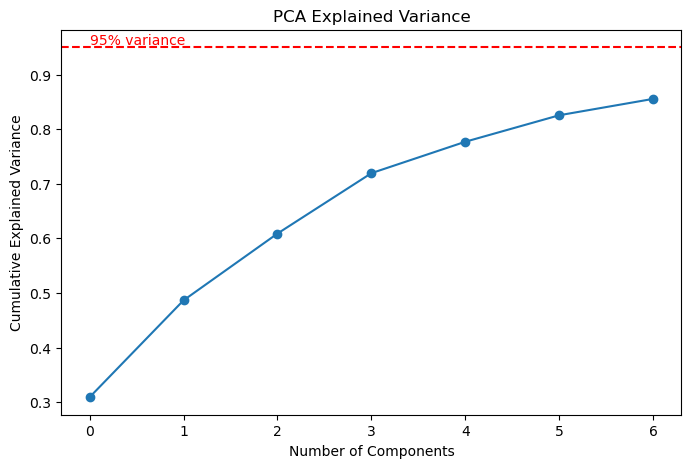

In [84]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

seg = slicer.slice_modalities_by_movie_time_sec(data[41], 0.0, 10.0)

X = seg["lfp_micro"]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% variance'
)

plt.text(
    x=0,
    y=0.95,
    s="95% variance",
    color='r',
    ha='left',
    va='bottom'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

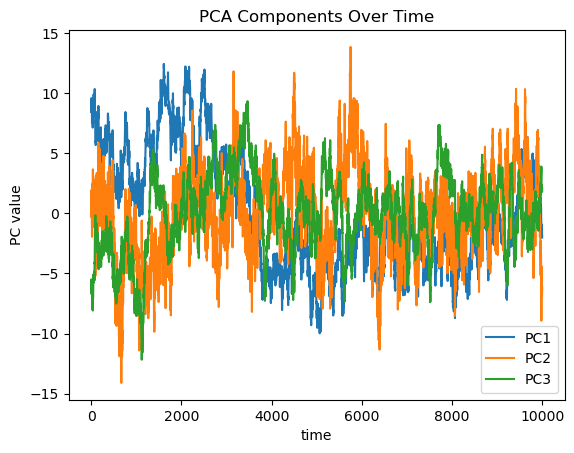

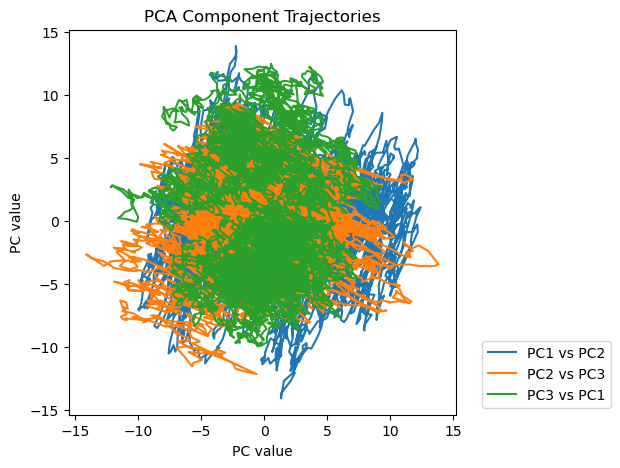

In [85]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.plot(X_pca[:, i], label=f'PC{i+1}')

plt.legend()
plt.xlabel("time")
plt.ylabel("PC value")
plt.title("PCA Components Over Time")
plt.show()

plt.figure(figsize=(5, 5))
for i in range(3):
    j = (i + 1) % 3
    plt.plot(X_pca[:, i], X_pca[:, j],label=f'PC{i+1} vs PC{j+1}')
    

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.xlabel("PC value")
plt.ylabel("PC value")
plt.title("PCA Component Trajectories")
plt.axis('equal')
plt.show()

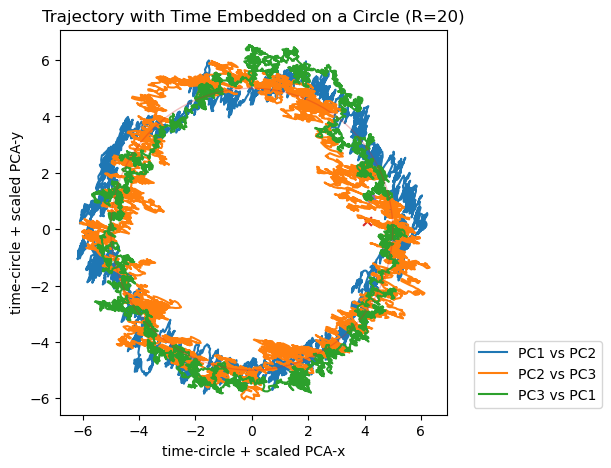

In [86]:
import numpy as np
import matplotlib.pyplot as plt

R = 5
T = X_pca.shape[0]
theta = np.linspace(0, 2*np.pi, T, endpoint=True)

plt.figure(figsize=(5, 5))

for i in range(3):
    j = (i + 1) % 3

    x = X_pca[:, i]
    y = X_pca[:, j]

    p95 = np.percentile(np.sqrt(x**2 + y**2), 95)
    s = (0.25 * R) / (p95 + 1e-9)

    cx = R * np.cos(theta)
    cy = R * np.sin(theta)

    X = cx + s * x
    Y = cy + s * y

    plt.plot(X, Y, label=f'PC{i+1} vs PC{j+1}')

    plt.scatter(X[0],  Y[0],  s=40, marker='o')
    plt.scatter(X[-1], Y[-1], s=40, marker='x')

tt = np.linspace(0, 2*np.pi, 400)
plt.plot(R*np.cos(tt), R*np.sin(tt), linewidth=1, alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.axis('equal')
plt.xlabel("time-circle + scaled PCA-x")
plt.ylabel("time-circle + scaled PCA-y")
plt.title("Trajectory with Time Embedded on a Circle (R=20)")
plt.show()

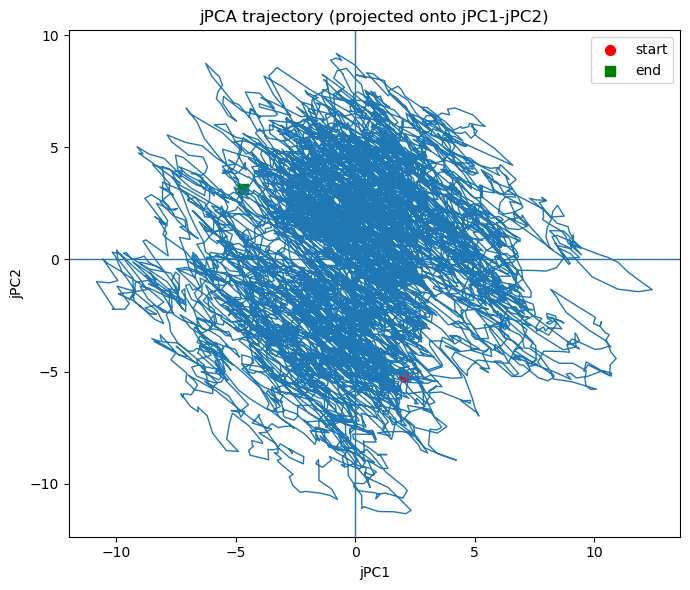

In [87]:
import numpy as np
import matplotlib.pyplot as plt

def finite_diff(X, dt=1.0):
    """Centered finite difference for dX/dt (same length as X)."""
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0]    = (X[1] - X[0]) / dt
    dX[-1]   = (X[-1] - X[-2]) / dt
    return dX

def fit_skew_M(X, dX):
    """
    Fit skew-symmetric M to minimize ||dX - X M^T||_F
    with constraint M^T = -M.
    """
    T, D = X.shape
    assert dX.shape == X.shape

    # Build linear system A m = b for upper-triangular free params of M
    # Parameterize M by entries m_ij for i<j, with:
    # M[i,j]=m_ij, M[j,i]=-m_ij, diag=0.
    pairs = [(i, j) for i in range(D) for j in range(i+1, D)]
    P = len(pairs)

    A = np.zeros((T * D, P), dtype=float)
    b = dX.reshape(-1)

    # For each time t and row k:
    # (X M^T)[t,k] = sum_l X[t,l] * M[k,l]
    # and M[k,l] expressed via m_ij.
    row = 0
    for t in range(T):
        x = X[t]
        for k in range(D):
            for p_idx, (i, j) in enumerate(pairs):
                val = 0.0
                # contribution from M[k,i] and M[k,j] if they exist
                # M[k,l] is:
                #  - if k==i and l==j: +m_ij
                #  - if k==j and l==i: -m_ij
                #  - if k==j and l==i handled similarly, etc.
                if k == i:
                    # term X[t, j] * M[i, j] = X_j * (+m_ij)
                    val += x[j]
                elif k == j:
                    # term X[t, i] * M[j, i] = X_i * (-m_ij)
                    val -= x[i]
                # also need terms where l==k and k==i/j? already covered above (since M[k,l])
                A[row, p_idx] = val
            row += 1

    # Solve least squares
    m_hat, *_ = np.linalg.lstsq(A, b, rcond=None)

    # Reconstruct M
    D = X.shape[1]
    M = np.zeros((D, D), dtype=float)
    for p_idx, (i, j) in enumerate(pairs):
        M[i, j] = m_hat[p_idx]
        M[j, i] = -m_hat[p_idx]
    return M

def jpca(X, dt=1.0, center=True):
    """
    X: (T, D) single trajectory (time-ordered).
    Returns:
      Xc: centered X used for fit
      M: skew-symmetric fitted dynamics
      W: (D,2) jPC plane basis
      Z: (T,2) projected trajectory in jPC plane
    """
    X_use = X.copy()
    if center:
        X_use = X_use - X_use.mean(axis=0, keepdims=True)

    dX = finite_diff(X_use, dt=dt)
    M = fit_skew_M(X_use, dX)

    # For skew-symmetric M, eigenvalues are ± iω. Take the pair with largest |ω|.
    evals, evecs = np.linalg.eig(M)
    omegas = np.abs(np.imag(evals))
    idx = np.argsort(omegas)[::-1]

    # pick the first eigenvector; its conjugate spans the same 2D plane
    v = evecs[:, idx[0]]
    W = np.column_stack([np.real(v), np.imag(v)])  # (D,2)

    # Orthonormalize W
    W, _ = np.linalg.qr(W)

    Z = X_use @ W
    return X_use, M, W, Z

# ====== X_pca jPCA ======
X = X_pca[:, :6]
dt = 1/30

Xc, M, W, Z = jpca(X, dt=dt, center=True)

# ====== jPC1 vs jPC2 ======
plt.figure(figsize=(7, 6))
plt.plot(Z[:, 0], Z[:, 1], lw=1)
plt.scatter(Z[0, 0], Z[0, 1], s=50, color='red', marker='o', label='start')
plt.scatter(Z[-1, 0], Z[-1, 1], s=50, color='green', marker='s', label='end')
plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel("jPC1")
plt.ylabel("jPC2")
plt.title("jPCA trajectory (projected onto jPC1-jPC2)")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Face Encoding Model

In [89]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

alpha = 10.0

def ridge_encoding_cv_single_output(X, y, alpha=alpha, n_splits=5):
    """
    contiguous block CV
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    X = X[valid]
    y = y[valid]

    T = len(y)
    if T < n_splits:
        return {"corr": np.nan, "r2": np.nan, "pred": np.full(T, np.nan)}

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full(T, np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr[:, None]).ravel()

        model = Ridge(alpha=alpha)
        model.fit(xtr, ytr_z)

        yhat_z = model.predict(xte)
        yhat = y_scaler.inverse_transform(yhat_z[:, None]).ravel()
        preds[te_idx] = yhat

    valid_pred = np.isfinite(preds)
    if valid_pred.sum() < 3:
        return {"corr": np.nan, "r2": np.nan, "pred": preds}

    yv = y[valid_pred]
    pv = preds[valid_pred]

    corr = np.corrcoef(yv, pv)[0, 1] if np.std(yv) > 0 and np.std(pv) > 0 else np.nan
    r2 = 1.0 - np.sum((yv - pv) ** 2) / np.sum((yv - np.mean(yv)) ** 2) if np.var(yv) > 0 else np.nan

    return {"corr": corr, "r2": r2, "pred": preds}

def flatten_targets(Y, target_prefix):
    """
    Input
    -----
    Y:
      [T]                  -> 1 target
      [T, C]               -> C targets
      [T, C, B]            -> C*B targets

    Returns
    -------
    Y2d: [T, N_targets]
    target_names: list[str]
    """
    Y = np.asarray(Y, dtype=float)

    if Y.ndim == 1:
        return Y[:, None], [f"{target_prefix}_0"]

    elif Y.ndim == 2:
        n = Y.shape[1]
        names = [f"{target_prefix}_{i}" for i in range(n)]
        return Y, names

    elif Y.ndim == 3:
        T, A, B = Y.shape
        Y2d = Y.reshape(T, A * B)
        names = [f"{target_prefix}_{a}_{b}" for a in range(A) for b in range(B)]
        return Y2d, names

    else:
        raise ValueError(f"Unsupported Y.ndim={Y.ndim}")
    
def run_encoding_for_modality(
    X,
    Y,
    modality_name,
    alpha=alpha,
    n_splits=5,
    max_targets=None,
):
    """
    X: [T, D]
    Y: [T], [T, C], or [T, C, B]
    """
    Y2d, target_names = flatten_targets(Y, modality_name)

    if max_targets is not None:
        Y2d = Y2d[:, :max_targets]
        target_names = target_names[:max_targets]

    rows = []
    for j, target_name in enumerate(target_names):
        y = Y2d[:, j]
        res = ridge_encoding_cv_single_output(X, y, alpha=alpha, n_splits=n_splits)

        rows.append({
            "modality": modality_name,
            "target": target_name,
            "corr": res["corr"],
            "r2": res["r2"],
        })

    return pd.DataFrame(rows)

def run_face_encoding_all_modalities(
    df_face_note,
    sub_dict,
    face_feature_sets,
    method_map=None,
    lags_sec=(-0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5),
    alpha=alpha,
    n_splits=5,
    max_targets_per_modality=None,
):
    t_grid = np.asarray(sub_dict["time_grid"], dtype=float)
    dt = float(np.median(np.diff(t_grid)))
    lags = np.round(np.asarray(lags_sec) / dt).astype(int)

    all_face_cols = sorted(set(sum(face_feature_sets.values(), [])))

    df_face_grid = slicer.resample_face_df_to_timegrid(
        df_face_note,
        t_grid,
        all_face_cols,
        method_map=method_map,
    )

    results = []

    for model_name, cols in face_feature_sets.items():
        X = df_face_grid[cols].astype(float).to_numpy()
        X_lag = feature.make_lagged_matrix(X, lags)

        modality_specs = {
            "firing_rate": sub_dict.get("firing_rate", None),
            "lfp_macro": sub_dict.get("lfp_macro", None),
            "lfp_micro": sub_dict.get("lfp_micro", None),
            "lfp_bandpower": sub_dict.get("lfp_bandpower", None),
            "pupil": sub_dict.get("pupil", None),
            "eye_gaze": sub_dict.get("eye_gaze", None),
        }

        for modality_name, Y in modality_specs.items():
            if Y is None:
                continue

            try:
                df_res = run_encoding_for_modality(
                    X=X_lag,
                    Y=Y,
                    modality_name=modality_name,
                    alpha=alpha,
                    n_splits=n_splits,
                    max_targets=max_targets_per_modality,
                )
                df_res["model_name"] = model_name
                results.append(df_res)
            except Exception as e:
                results.append(pd.DataFrame([{
                    "modality": modality_name,
                    "target": None,
                    "corr": np.nan,
                    "r2": np.nan,
                    "model_name": model_name,
                    "error": repr(e),
                }]))

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, axis=0, ignore_index=True)

In [90]:
face_feature_sets = {
    "quantity": ["n_faces", "total_face_area", "max_face_area"],
    "identity": ["Jacky_present"],
    "pose_emotion": [
        "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ],
    "all_face": [
        "n_faces", "total_face_area", "max_face_area",
        "Jacky_present", "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ]
}

method_map = {
    "n_faces": "nearest",
    "total_face_area": "linear",
    "max_face_area": "linear",
    "Jacky_present": "nearest",
    "any_front_face": "nearest",
    "emo_afraid": "nearest",
    "emo_angry": "nearest",
    "emo_happy": "nearest",
    "emo_neutral": "nearest",
    "emo_surprised": "nearest",
}

sub = list(data.keys())[0]

df_result = run_face_encoding_all_modalities(
    df_face_note=df_face_note,
    sub_dict=data[sub],
    face_feature_sets=face_feature_sets,
    method_map=method_map,
    lags_sec=(-0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5),
    alpha=alpha,
    n_splits=5,
    max_targets_per_modality=20,
)

print(df_result)

          modality         target      corr        r2 model_name  \
0      firing_rate  firing_rate_0  0.001070 -0.000340   quantity   
1      firing_rate  firing_rate_1  0.004998 -0.000175   quantity   
2      firing_rate  firing_rate_2 -0.002683 -0.000699   quantity   
3      firing_rate  firing_rate_3 -0.000456 -0.000394   quantity   
4      firing_rate  firing_rate_4 -0.001302 -0.000797   quantity   
..             ...            ...       ...       ...        ...   
199      lfp_micro   lfp_micro_19  0.001178 -0.182616   all_face   
200  lfp_bandpower           None       NaN       NaN   all_face   
201          pupil        pupil_0 -0.159965 -0.412478   all_face   
202       eye_gaze     eye_gaze_0 -0.070719 -0.320026   all_face   
203       eye_gaze     eye_gaze_1  0.094172 -0.427356   all_face   

                                                 error  
0                                                  NaN  
1                                                  NaN  
2           

In [91]:
df_result.groupby(["modality", "model_name"])[["corr", "r2"]].mean()

corr        r2
modality      model_name                      
eye_gaze      all_face      0.011727 -0.373691
              identity     -0.036863 -0.023362
              pose_emotion -0.121048 -0.073494
              quantity     -0.058119 -0.158100
firing_rate   all_face      0.000555 -0.001158
              identity     -0.003987 -0.000144
              pose_emotion -0.003238 -0.000187
              quantity      0.000208 -0.000437
lfp_bandpower all_face           NaN       NaN
              identity           NaN       NaN
              pose_emotion       NaN       NaN
              quantity           NaN       NaN
lfp_macro     all_face      0.002869 -0.110572
              identity      0.032132 -0.009502
              pose_emotion -0.004661 -0.006938
              quantity     -0.023686 -0.113892
lfp_micro     all_face      0.043206 -0.188743
              identity      0.005793 -0.019675
              pose_emotion -0.054050 -0.015901
              quantity      0.043161 -0.160423
pupil         all_face     -0.159965 -0.412478
              identity     -0.234273 -0.069847
              pose_emotion -0.197248 -0.097687
              quantity     -0.116229 -0.158741


===== firing_rate =====


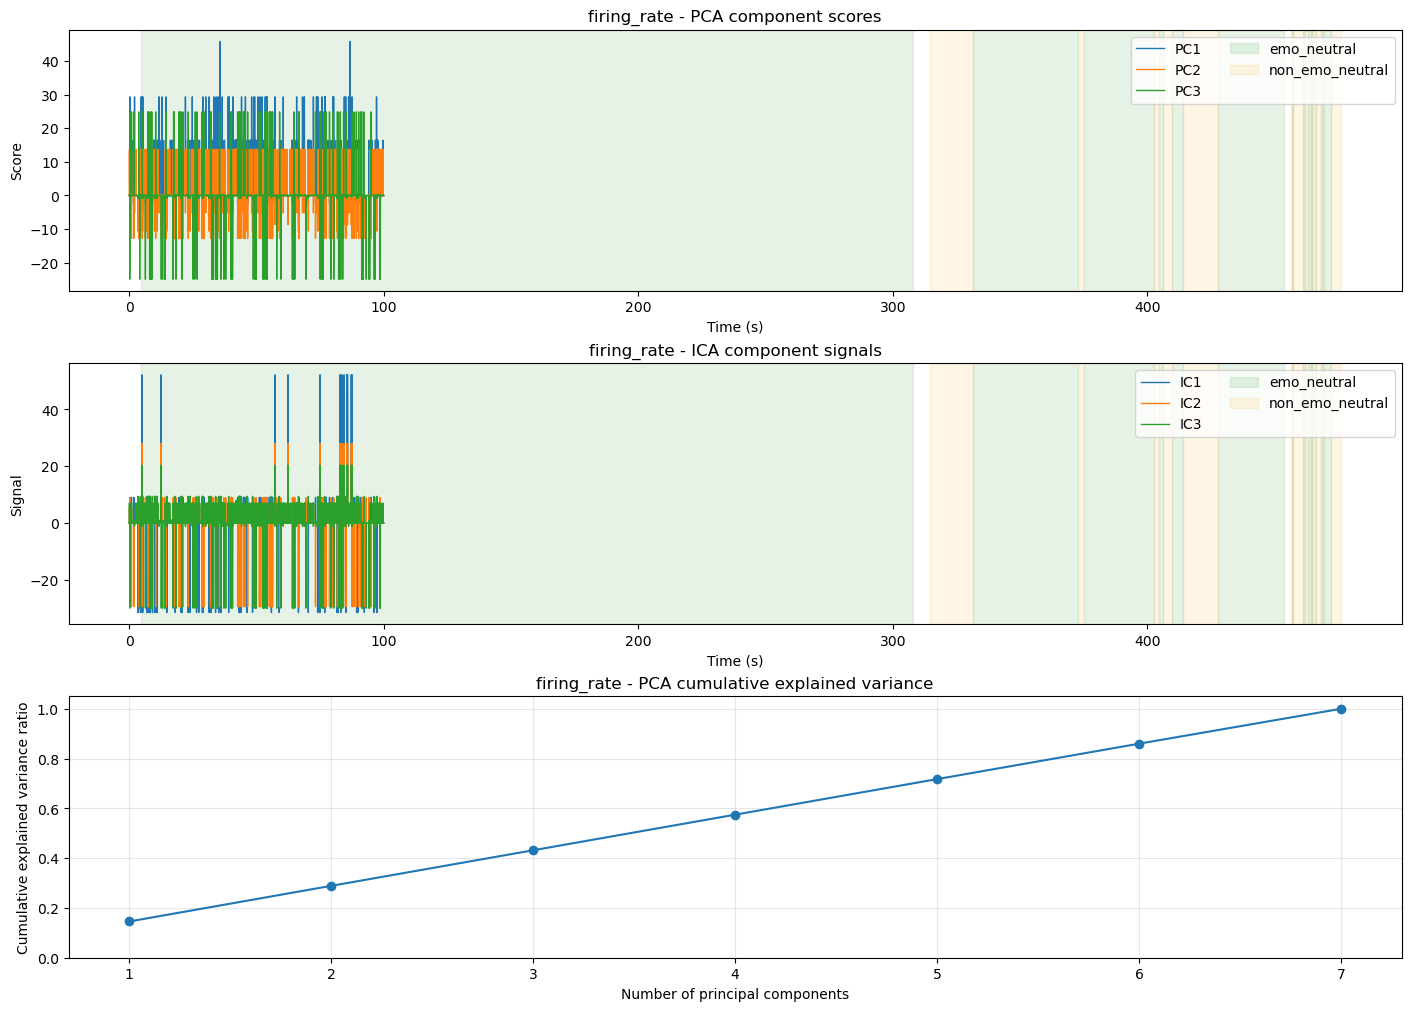


===== lfp_macro =====


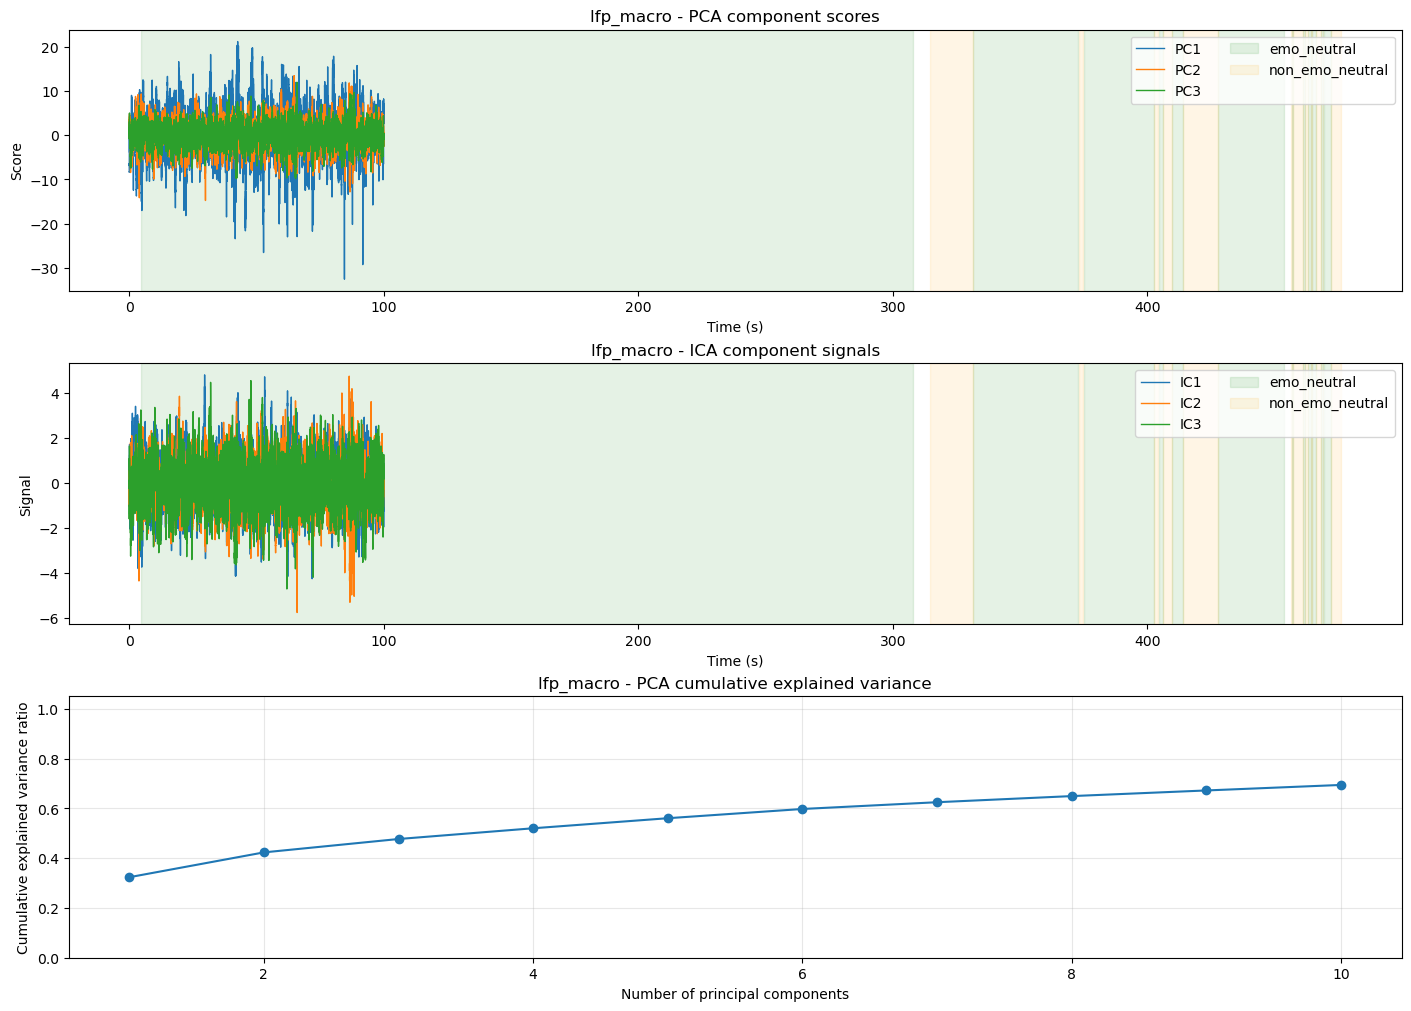


===== lfp_micro =====


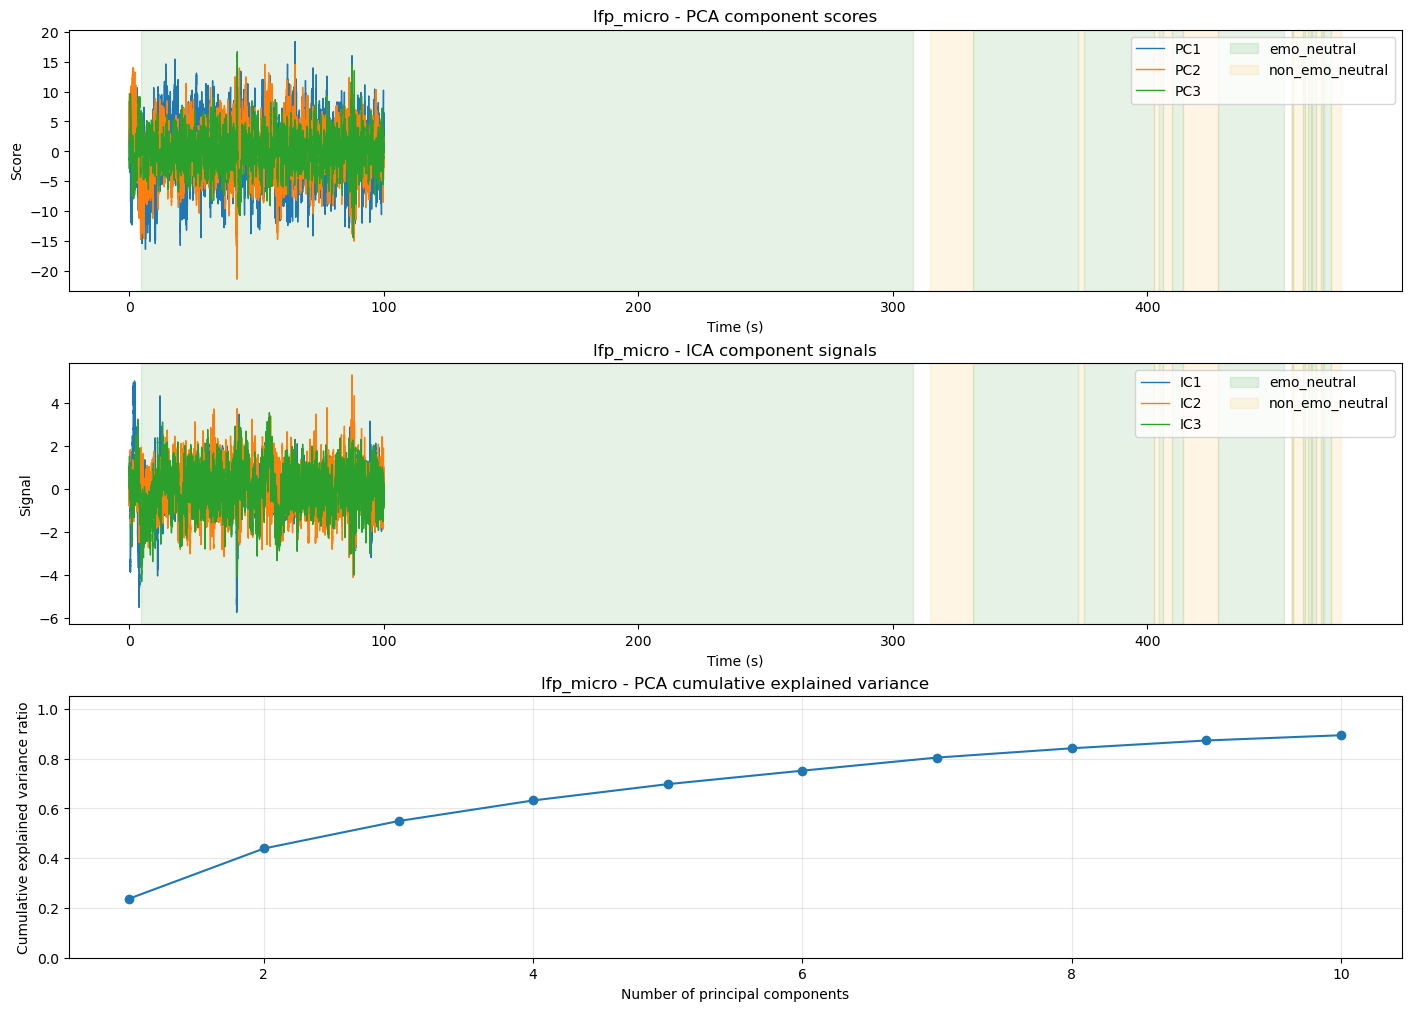


===== eye_gaze =====


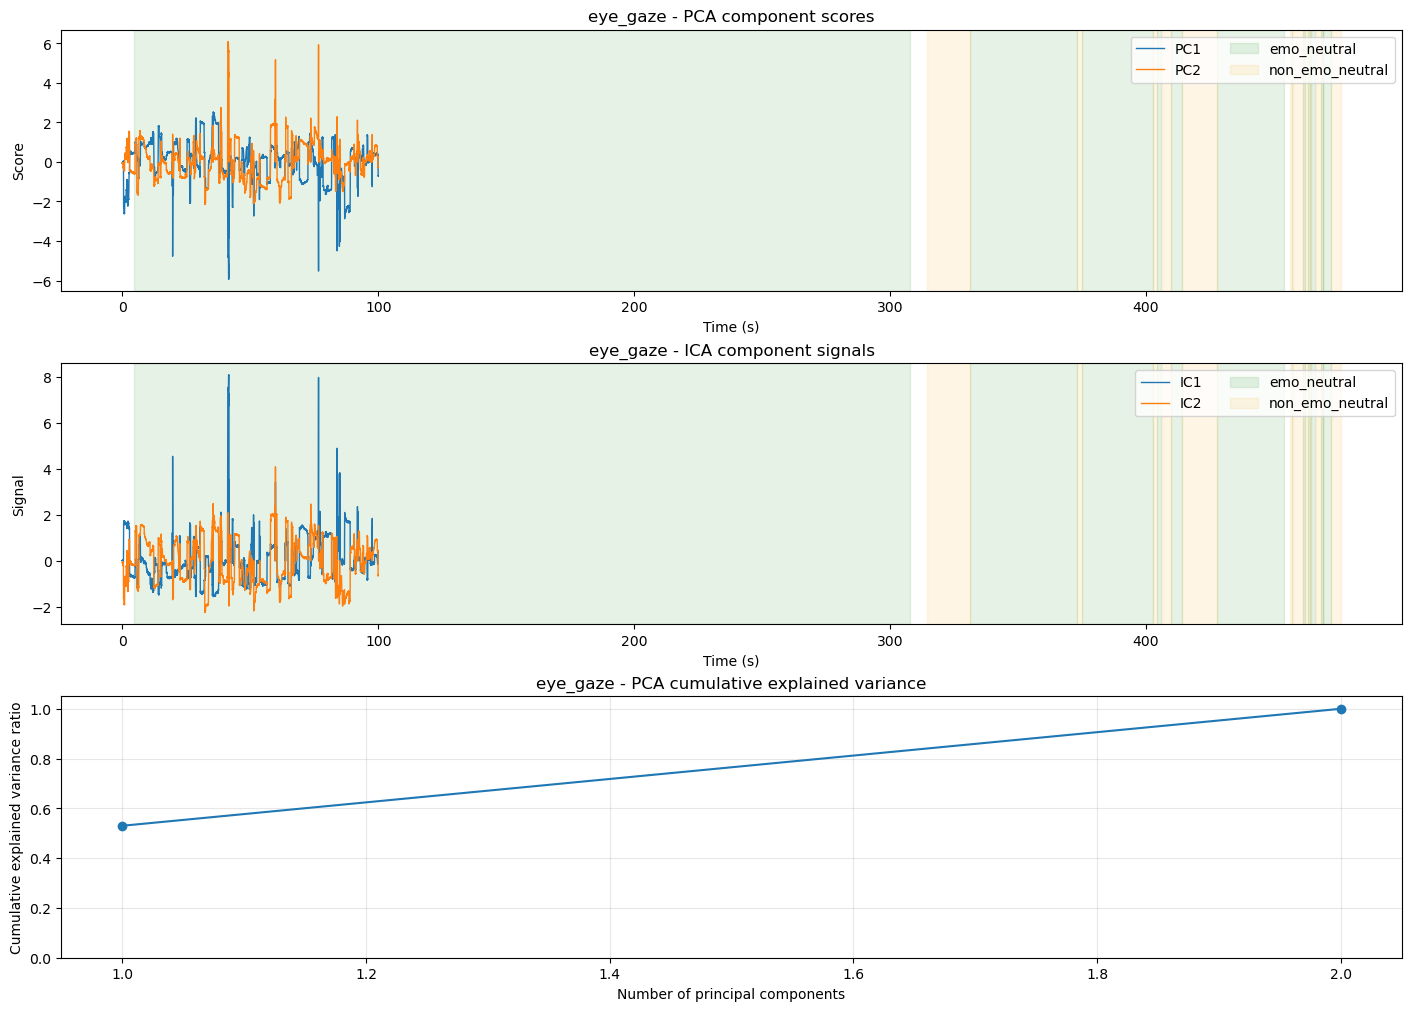


===== pupil =====
[skip] pupil: effective feature dim < 2 after cleaning


In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler


# =========================
# 1. 基础工具
# =========================
def _ensure_2d_time_by_feature(x, target_len=None, name="modality"):
    """
    尽量把输入整理成 [T, D] 形式。
    支持:
      - 1D: [T] -> [T, 1]
      - 2D: [T, D] or [D, T]
      - 3D+: 若某一维等于 target_len，则把那一维移到前面并 flatten 其余维
    """
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        return x[:, None]

    if x.ndim == 2:
        # 如果给了 target_len，就优先让第一维=T
        if target_len is not None:
            if x.shape[0] == target_len:
                return x
            elif x.shape[1] == target_len:
                return x.T
        # 否则默认第一维是时间
        return x

    # ndim >= 3
    if target_len is not None:
        axes = list(range(x.ndim))
        time_axis = None
        for ax, s in enumerate(x.shape):
            if s == target_len:
                time_axis = ax
                break
        if time_axis is not None:
            x = np.moveaxis(x, time_axis, 0)   # [T, ...]
            T = x.shape[0]
            return x.reshape(T, -1)

    # fallback: 默认第一维是时间
    T = x.shape[0]
    return x.reshape(T, -1)


def _fill_nan_2d(X):
    """
    对 [T, D] 矩阵按列填 NaN:
    - 先用列均值填
    - 若整列全 NaN，则填 0
    """
    X = np.asarray(X, dtype=np.float64).copy()
    col_mean = np.nanmean(X, axis=0)

    # 整列全nan -> nanmean会是nan，这里置0
    col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)

    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_mean, inds[1])
    return X


def get_time_axis_for_modality(sub_data, modality):
    """
    给每个模态找一个时间轴（秒）。
    优先：
      1) resampled continuous modality -> time_grid
      2) 若长度和 movieframe_time_sec 一致 -> movieframe_time_sec
      3) 若存在 raw time -> time_raw[...]
    """
    arr = sub_data.get(modality, None)
    if arr is None:
        return None

    time_grid = np.asarray(sub_data.get("time_grid", []), dtype=np.float64)
    movie_t = np.asarray(sub_data.get("movieframe_time_sec", []), dtype=np.float64)

    # raw time
    time_raw_dict = sub_data.get("time_raw", {})
    raw_key_map = {
        "lfp_macro": "lfp_macro",
        "lfp_micro": "lfp_micro",
        "eye_gaze": "eye",
        "pupil": "eye",
    }
    raw_t = None
    if modality in raw_key_map and raw_key_map[modality] in time_raw_dict:
        raw_t = time_raw_dict[raw_key_map[modality]]
        if raw_t is not None:
            raw_t = np.asarray(raw_t, dtype=np.float64)

    # 先猜长度
    candidate = _ensure_2d_time_by_feature(arr, target_len=len(time_grid), name=modality)
    if candidate is not None and len(time_grid) > 0 and candidate.shape[0] == len(time_grid):
        return time_grid

    if len(movie_t) > 0:
        candidate = _ensure_2d_time_by_feature(arr, target_len=len(movie_t), name=modality)
        if candidate is not None and candidate.shape[0] == len(movie_t):
            return movie_t

    if raw_t is not None:
        candidate = _ensure_2d_time_by_feature(arr, target_len=len(raw_t), name=modality)
        if candidate is not None and candidate.shape[0] == len(raw_t):
            return raw_t

    # fallback
    X = _ensure_2d_time_by_feature(arr, target_len=None, name=modality)
    if X is None:
        return None
    return np.arange(X.shape[0], dtype=np.float64)


# =========================
# 2. annotation 区间提取
# =========================
def extract_boolean_spans(time_arr, flag_arr):
    """
    根据 time_arr 和布尔 flag_arr 提取连续区间 [(start, end), ...]
    """
    time_arr = np.asarray(time_arr, dtype=np.float64)
    flag_arr = np.asarray(flag_arr).astype(bool)

    assert len(time_arr) == len(flag_arr)

    spans = []
    if len(time_arr) == 0:
        return spans

    in_span = False
    start_t = None

    for i in range(len(flag_arr)):
        if flag_arr[i] and not in_span:
            in_span = True
            start_t = time_arr[i]
        elif (not flag_arr[i]) and in_span:
            end_t = time_arr[i - 1]
            spans.append((start_t, end_t))
            in_span = False
            start_t = None

    if in_span:
        spans.append((start_t, time_arr[-1]))

    return spans


def get_emotion_spans(df_face):
    """
    从 face annotation dataframe 中提取
      - neutral spans
      - non-neutral spans
    需要列:
      - movie_time
      - emo_neutral
    """
    df = df_face.copy().sort_values("movie_time").reset_index(drop=True)

    if "emo_neutral" not in df.columns:
        raise ValueError("df_face 里没有 'emo_neutral' 列")
    if "movie_time" not in df.columns:
        raise ValueError("df_face 里没有 'movie_time' 列")

    movie_time = df["movie_time"].to_numpy(dtype=np.float64)
    neutral_flag = df["emo_neutral"].astype(bool).to_numpy()
    nonneutral_flag = ~neutral_flag

    neutral_spans = extract_boolean_spans(movie_time, neutral_flag)
    nonneutral_spans = extract_boolean_spans(movie_time, nonneutral_flag)

    return neutral_spans, nonneutral_spans


def add_emotion_spans(ax, neutral_spans, nonneutral_spans,
                      neutral_alpha=0.10, nonneutral_alpha=0.10):
    """
    在时间图上标注 neutral / non-neutral 区间
    """
    # neutral: 浅绿色
    for i, (s, e) in enumerate(neutral_spans):
        ax.axvspan(
            s, e,
            alpha=neutral_alpha,
            color="green",
            label="emo_neutral" if i == 0 else None
        )

    # non-neutral: 浅橙色
    for i, (s, e) in enumerate(nonneutral_spans):
        ax.axvspan(
            s, e,
            alpha=nonneutral_alpha,
            color="orange",
            label="non_emo_neutral" if i == 0 else None
        )


# =========================
# 3. 单模态 PCA/ICA + 作图
# =========================
def analyze_one_modality(
    sub_data,
    modality,
    df_face,
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
    figsize=(14, 10)
):
    """
    对一个模态:
      - 整理成 [T, D]
      - PCA
      - ICA
      - 画:
          1) PCA前几个score的时间图
          2) ICA前几个source的时间图
          3) PCA累计解释方差图
    """
    arr = sub_data.get(modality, None)
    if arr is None:
        print(f"[skip] {modality}: not found in sub_data")
        return None

    t = get_time_axis_for_modality(sub_data, modality)
    if t is None:
        print(f"[skip] {modality}: no valid time axis")
        return None

    X = _ensure_2d_time_by_feature(arr, target_len=len(t), name=modality)
    if X is None:
        print(f"[skip] {modality}: cannot convert to 2D")
        return None

    # 再检查一下长度是否匹配
    if X.shape[0] != len(t):
        print(f"[skip] {modality}: time length mismatch, X={X.shape}, len(t)={len(t)}")
        return None

    # 去掉全常数列/全nan列前先填nan
    X = _fill_nan_2d(X)

    # 去掉方差为0的列
    col_std = np.std(X, axis=0)
    keep = col_std > 1e-12
    X = X[:, keep]

    if X.shape[1] < 2:
        print(f"[skip] {modality}: effective feature dim < 2 after cleaning")
        return None

    # 标准化
    if standardize:
        scaler = StandardScaler()
        Xz = scaler.fit_transform(X)
    else:
        Xz = X.copy()

    # PCA
    pca_k = min(n_pca, Xz.shape[0], Xz.shape[1])
    pca = PCA(n_components=pca_k, random_state=0)
    X_pca = pca.fit_transform(Xz)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    # ICA
    ica_k = min(n_ica, Xz.shape[0], Xz.shape[1])
    ica = FastICA(n_components=ica_k, random_state=0, max_iter=2000, tol=1e-4)
    try:
        X_ica = ica.fit_transform(Xz)
        ica_ok = True
    except Exception as e:
        print(f"[warn] {modality}: ICA failed -> {e}")
        X_ica = None
        ica_ok = False

    # emotion spans
    neutral_spans, nonneutral_spans = get_emotion_spans(df_face)

    # ========== Plot ==========
    fig, axes = plt.subplots(3, 1, figsize=figsize, constrained_layout=True)

    # 1) PCA score time series
    ax = axes[0]
    n_show_pca = min(plot_n_comp, X_pca.shape[1])
    for i in range(n_show_pca):
        ax.plot(t, X_pca[:, i], label=f"PC{i+1}", linewidth=1.0)
    add_emotion_spans(ax, neutral_spans, nonneutral_spans)
    ax.set_title(f"{modality} - PCA component scores")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Score")
    ax.legend(loc="upper right", ncol=2)

    # 2) ICA source time series
    ax = axes[1]
    if ica_ok and X_ica is not None:
        n_show_ica = min(plot_n_comp, X_ica.shape[1])
        for i in range(n_show_ica):
            ax.plot(t, X_ica[:, i], label=f"IC{i+1}", linewidth=1.0)
        add_emotion_spans(ax, neutral_spans, nonneutral_spans)
        ax.set_title(f"{modality} - ICA component signals")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.legend(loc="upper right", ncol=2)
    else:
        ax.text(0.5, 0.5, f"ICA failed for {modality}", ha="center", va="center", fontsize=12)
        ax.set_title(f"{modality} - ICA component signals")
        ax.set_axis_off()

    # 3) Cumulative explained variance
    ax = axes[2]
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o")
    ax.set_title(f"{modality} - PCA cumulative explained variance")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative explained variance ratio")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    plt.show()

    return {
        "modality": modality,
        "time": t,
        "X": X,
        "pca_model": pca,
        "pca_scores": X_pca,
        "cum_explained_variance": cumvar,
        "ica_model": ica if ica_ok else None,
        "ica_sources": X_ica,
        "neutral_spans": neutral_spans,
        "nonneutral_spans": nonneutral_spans,
    }


# =========================
# 4. 批量分析多个模态
# =========================
def analyze_modalities(
    sub_data,
    df_face,
    modalities=None,
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
):
    if modalities is None:
        modalities = [
            "firing_rate",
            "lfp_macro",
            "lfp_micro",
            "lfp_bandpower",
            "eye_gaze",
            "pupil",
        ]

    results = {}
    for modality in modalities:
        print(f"\n===== {modality} =====")
        res = analyze_one_modality(
            sub_data=sub_data,
            modality=modality,
            df_face=df_face,
            n_pca=n_pca,
            n_ica=n_ica,
            standardize=standardize,
            plot_n_comp=plot_n_comp,
        )
        results[modality] = res

    return results
results = analyze_modalities(
    sub_data=data[sub],
    df_face=df_face_note,
    modalities=[
        "firing_rate",
        "lfp_macro",
        "lfp_micro",
        "eye_gaze",
        "pupil",
    ],
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
)

In [93]:
from numpy.linalg import lstsq, eig
from scipy.signal import detrend

def compute_jpca(X, dt):
    """
    X: [T, D]
    dt: scalar
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}")
    if X.shape[0] < 3:
        raise ValueError(f"Need at least 3 time points, got shape={X.shape}")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError(f"dt must be positive finite, got dt={dt}")

    # 对齐成:
    # X_prev[t] 对应 dX[t] = (X[t+1]-X[t]) / dt
    X_prev = X[:-1]                    # [T-1, D]
    dX = np.diff(X, axis=0) / dt       # [T-1, D]

    # fit: dX = X_prev @ M
    M, _, _, _ = lstsq(X_prev, dX, rcond=None)   # M shape [D, D]

    # 旋转部分
    M_skew = 0.5 * (M - M.T)

    eigvals, eigvecs = eig(M_skew)
    return M, M_skew, eigvals, eigvecs

def project_to_jpca_plane(X, eigvecs, eigvals):
    """
    取虚部最大的那一对特征向量，构造2D jPCA plane
    """
    imag_strength = np.abs(np.imag(eigvals))
    idx = np.argsort(imag_strength)[-2:]

    W = np.real(eigvecs[:, idx])   # [D, 2]
    X_jpca = X @ W                 # [T, 2]
    return X_jpca, W, idx


def plot_jpca_trajectory(X_jpca, modality):
    plt.figure(figsize=(5, 5))
    plt.plot(X_jpca[:, 0], X_jpca[:, 1], linewidth=1)
    plt.scatter(X_jpca[0, 0], X_jpca[0, 1], label="start")
    plt.scatter(X_jpca[-1, 0], X_jpca[-1, 1], label="end")
    plt.xlabel("jPC1")
    plt.ylabel("jPC2")
    plt.title(f"{modality} jPCA plane")
    plt.legend()
    plt.axis("equal")
    plt.show()


def run_jpca_on_result(res, n_input_pc=6):
    X = np.asarray(res["pca_scores"], dtype=np.float64)
    X = detrend(X, axis=0)
    t = np.asarray(res["time"], dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"pca_scores must be 2D, got {X.shape}")
    if len(t) != X.shape[0]:
        raise ValueError(f"time length {len(t)} != X rows {X.shape[0]}")
    if len(t) < 3:
        raise ValueError(f"Need at least 3 time points, got {len(t)}")

    # 去掉非有限时间差
    dt_all = np.diff(t)
    dt_all = dt_all[np.isfinite(dt_all) & (dt_all > 0)]
    if len(dt_all) == 0:
        raise ValueError("No valid positive dt found in time axis")
    dt = np.median(dt_all)

    # 限制输入维数
    k = min(n_input_pc, X.shape[1])
    X = X[:, :k]

    # 去掉含nan的行
    good = np.isfinite(X).all(axis=1) & np.isfinite(t)
    X = X[good]
    t = t[good]

    if X.shape[0] < 3:
        raise ValueError(f"Not enough valid rows after cleaning: {X.shape}")

    M, M_skew, eigvals, eigvecs = compute_jpca(X, dt)
    X_jpca, W, idx = project_to_jpca_plane(X, eigvecs, eigvals)

    plot_jpca_trajectory(X_jpca, res["modality"])

    print(f"{res['modality']} | input_dim={k}, T={X.shape[0]}, dt={dt:.6f}")
    print("eigenvalues:", eigvals)
    print("imag parts:", np.imag(eigvals))

    return {
        "X_jpca": X_jpca,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "W": W,
        "idx": idx,
        "M": M,
        "M_skew": M_skew,
        "dt": dt,
    }


==== firing_rate ====


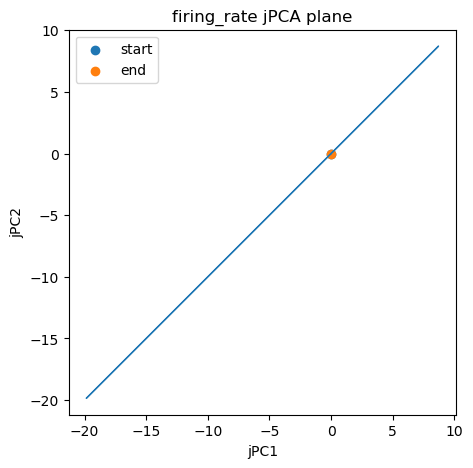

firing_rate | input_dim=6, T=100000, dt=0.001000
eigenvalues: [-6.14020846e-16+9.67147253e+00j -6.14020846e-16-9.67147253e+00j
  3.60479745e-16+2.62110542e+00j  3.60479745e-16-2.62110542e+00j
 -5.77037761e-17+4.30351292e-05j -5.77037761e-17-4.30351292e-05j]
imag parts: [ 9.67147253e+00 -9.67147253e+00  2.62110542e+00 -2.62110542e+00
  4.30351292e-05 -4.30351292e-05]

==== lfp_macro ====


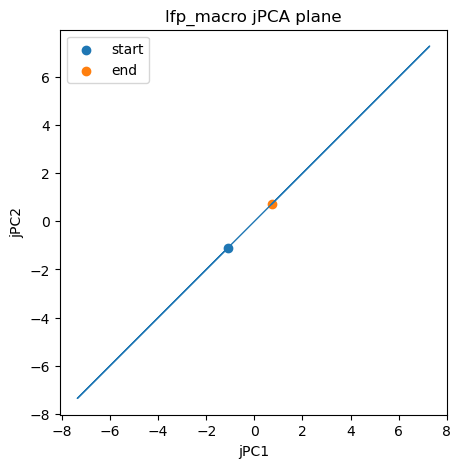

lfp_macro | input_dim=6, T=100000, dt=0.001000
eigenvalues: [-5.34322560e-16+8.77304656j -5.34322560e-16-8.77304656j
  3.26458684e-16+4.69711939j  3.26458684e-16-4.69711939j
 -7.41848992e-17+0.35215774j -7.41848992e-17-0.35215774j]
imag parts: [ 8.77304656 -8.77304656  4.69711939 -4.69711939  0.35215774 -0.35215774]

==== lfp_micro ====


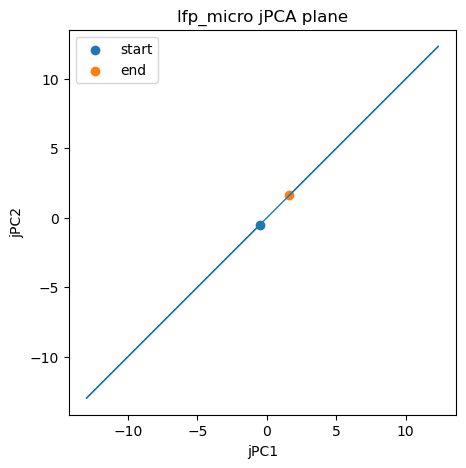

lfp_micro | input_dim=6, T=100000, dt=0.001000
eigenvalues: [1.35565476e-16+4.59641071j 1.35565476e-16-4.59641071j
 1.75241764e-16+1.96894469j 1.75241764e-16-1.96894469j
 7.99755613e-17+0.1231371j  7.99755613e-17-0.1231371j ]
imag parts: [ 4.59641071 -4.59641071  1.96894469 -1.96894469  0.1231371  -0.1231371 ]

==== eye_gaze ====


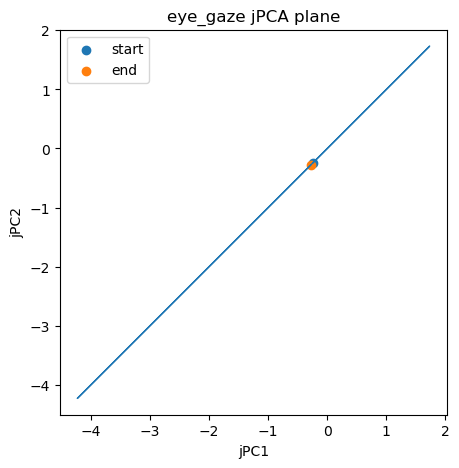

eye_gaze | input_dim=2, T=100000, dt=0.001000
eigenvalues: [0.+0.07390275j 0.-0.07390275j]
imag parts: [ 0.07390275 -0.07390275]


In [94]:
jpca_results = {}

for modality, res in results.items():
    if res is None:
        continue

    print("\n====", modality, "====")
    try:
        jpca_results[modality] = run_jpca_on_result(res, n_input_pc=6)
    except Exception as e:
        print(f"[skip] {modality}: {e}")

## Face Encoding Model with Generalized Linear Model implementation

In [95]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [ ]:
# Fast alpha screen for GLM face encoding
# Assumes these already exist from earlier cells:
# - data, df_face_note, face_feature_sets, method_map
# - slicer, feature, flatten_targets
# - run_encoding_for_modality_glm
# - df_result (optional; only needed later if you want full comparison)

import numpy as np
import pandas as pd

required_globals = [
    "data",
    "df_face_note",
    "face_feature_sets",
    "method_map",
    "slicer",
    "feature",
    "flatten_targets",
    "run_encoding_for_modality_glm",
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise NameError(
        "Missing required notebook variables/functions: "
        + ", ".join(missing)
        + ". Rerun the earlier setup + GLM definition cells first."
    )

sub_key = next(iter(data))


def run_face_encoding_all_modalities_glm(
    df_face_note,
    sub_dict,
    face_feature_sets,
    method_map=None,
    lags_sec=(0.0, 0.1, 0.2, 0.3),
    alpha=0.1,
    n_splits=5,
    max_targets_per_modality=None,
    modalities_to_run=None,
    model_names_to_run=None,
):
    """
    GLM-based face encoding using the already-defined
    run_encoding_for_modality_glm(), with optional filtering so we can
    screen alpha quickly on a smaller subset.
    """
    t_grid = np.asarray(sub_dict["time_grid"], dtype=float)
    dt = float(np.median(np.diff(t_grid)))
    lags = np.round(np.asarray(lags_sec) / dt).astype(int)

    if model_names_to_run is None:
        selected_feature_sets = face_feature_sets
    else:
        selected_feature_sets = {
            name: cols for name, cols in face_feature_sets.items()
            if name in model_names_to_run
        }
        if len(selected_feature_sets) == 0:
            raise ValueError("No matching model_names_to_run found in face_feature_sets.")

    all_face_cols = sorted({col for cols in selected_feature_sets.values() for col in cols})

    df_face_grid = slicer.resample_face_df_to_timegrid(
        df_face_note,
        t_grid,
        all_face_cols,
        method_map=method_map,
    )

    modality_specs_all = {
        "firing_rate": sub_dict.get("firing_rate", None),
        "lfp_macro": sub_dict.get("lfp_macro", None),
        "lfp_micro": sub_dict.get("lfp_micro", None),
        "lfp_bandpower": sub_dict.get("lfp_bandpower", None),
        "pupil": sub_dict.get("pupil", None),
        "eye_gaze": sub_dict.get("eye_gaze", None),
    }

    if modalities_to_run is None:
        modality_specs = modality_specs_all
    else:
        modality_specs = {
            name: modality_specs_all.get(name, None)
            for name in modalities_to_run
        }

    results = []

    for model_name, cols in selected_feature_sets.items():
        X = df_face_grid[cols].astype(float).to_numpy()
        X_lag = feature.make_lagged_matrix(X, lags)

        for modality_name, Y in modality_specs.items():
            if Y is None:
                continue

            try:
                df_res = run_encoding_for_modality_glm(
                    X=X_lag,
                    Y=Y,
                    modality_name=modality_name,
                    alpha=alpha,
                    n_splits=n_splits,
                    max_targets=max_targets_per_modality,
                )
                df_res["model_name"] = model_name
                results.append(df_res)
            except Exception as e:
                results.append(pd.DataFrame([{
                    "modality": modality_name,
                    "target": None,
                    "corr": np.nan,
                    "r2": np.nan,
                    "model_name": model_name,
                    "error": repr(e),
                }]))

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, axis=0, ignore_index=True)


def screen_alphas_glm(
    alphas,
    lags_sec=(0.0, 0.1, 0.2, 0.3),
    n_splits=5,
    max_targets_per_modality=5,
    modalities_to_run=("firing_rate", "lfp_macro", "lfp_micro", "pupil", "eye_gaze"),
    model_names_to_run=("quantity", "all_face"),
):
    """
    Cheap alpha screen.
    Picks the best alpha by mean corr across the screened subset,
    with mean r2 as a secondary tiebreaker.
    """
    summaries = []
    per_alpha_results = {}

    for alpha in alphas:
        print(f"\n=== Screening alpha={alpha} ===")

        df_alpha = run_face_encoding_all_modalities_glm(
            df_face_note=df_face_note,
            sub_dict=data[sub_key],
            face_feature_sets=face_feature_sets,
            method_map=method_map,
            lags_sec=lags_sec,
            alpha=alpha,
            n_splits=n_splits,
            max_targets_per_modality=max_targets_per_modality,
            modalities_to_run=modalities_to_run,
            model_names_to_run=model_names_to_run,
        )

        per_alpha_results[alpha] = df_alpha

        mean_corr = df_alpha["corr"].mean(skipna=True)
        mean_r2 = df_alpha["r2"].mean(skipna=True)
        median_corr = df_alpha["corr"].median(skipna=True)
        median_r2 = df_alpha["r2"].median(skipna=True)

        summaries.append({
            "alpha": alpha,
            "mean_corr": mean_corr,
            "mean_r2": mean_r2,
            "median_corr": median_corr,
            "median_r2": median_r2,
            "n_rows": len(df_alpha),
        })

        grouped = df_alpha.groupby(["modality", "model_name"])[["corr", "r2"]].mean()
        print(grouped)

    summary_df = pd.DataFrame(summaries).sort_values(
        ["mean_corr", "mean_r2"],
        ascending=False,
        ignore_index=True,
    )

    best_alpha = summary_df.loc[0, "alpha"]

    return best_alpha, summary_df, per_alpha_results


# -----------------------------
# Configure the cheap alpha screen
# -----------------------------
alpha_grid = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

screen_modalities = ("firing_rate", "lfp_macro", "lfp_micro", "pupil", "eye_gaze")
screen_models = ("quantity", "all_face")
screen_lags = (0.0, 0.1, 0.2, 0.3)

best_alpha, alpha_summary, alpha_results = screen_alphas_glm(
    alphas=alpha_grid,
    lags_sec=screen_lags,
    n_splits=5,
    max_targets_per_modality=5,
    modalities_to_run=screen_modalities,
    model_names_to_run=screen_models,
)

print("\n=== Alpha screening summary ===")
print(alpha_summary)

print(f"\nBest alpha on screened subset: {best_alpha}")

print("\n=== Grouped means for best alpha (screened subset) ===")
print(
    alpha_results[best_alpha]
    .groupby(["modality", "model_name"])[["corr", "r2"]]
    .mean()
)




=== Screening alpha=0.0 ===
                            corr        r2
modality    model_name                    
eye_gaze    all_face    0.022173 -0.331136
            quantity   -0.051770 -0.141512
firing_rate all_face   -0.000355 -0.001114
            quantity    0.000315 -0.000413
lfp_macro   all_face    0.023891 -0.140758
            quantity   -0.014597 -0.170342
lfp_micro   all_face    0.062458 -0.191172
            quantity    0.071667 -0.146282
pupil       all_face   -0.152647 -0.456095
            quantity   -0.104642 -0.208393

=== Screening alpha=0.001 ===
                            corr        r2
modality    model_name                    
eye_gaze    all_face    0.029124 -0.296288
            quantity   -0.046018 -0.116632
firing_rate all_face   -0.000410 -0.000627
            quantity    0.000584 -0.000235
lfp_macro   all_face    0.061278 -0.068092
            quantity   -0.001772 -0.095236
lfp_micro   all_face    0.052942 -0.157429
            quantity    0.063575 -0.1

In [112]:
# GLM face encoding with smoothed discrete face predictors
alpha = 0.1
sub_key = sub if "sub" in globals() else next(iter(data))

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Keep this local so the cell is self-contained
lags_sec = (0.0, 0.1, 0.2, 0.3)

# Smoothing controls
smooth_sec = 0.30  # try 0.2, 0.3, 0.5
smooth_cols = [
    "Jacky_present",
    "any_front_face",
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised",
    # "n_faces",  # optional: uncomment if you want this softened too
]


def smooth_face_predictors(df_face_grid, cols_to_smooth, dt, smooth_sec=0.30):
    """
    Smooth selected discrete/step-like predictors with a centered rolling mean.
    This turns binary step functions into soft occupancy-like regressors.

    Parameters
    ----------
    df_face_grid : pd.DataFrame
    cols_to_smooth : list[str]
    dt : float
    smooth_sec : float
    """
    df_sm = df_face_grid.copy()

    if smooth_sec is None or smooth_sec <= 0:
        return df_sm

    win = max(1, int(round(float(smooth_sec) / float(dt))))
    if win % 2 == 0:
        win += 1

    for col in cols_to_smooth:
        if col not in df_sm.columns:
            continue

        x = pd.Series(df_sm[col].astype(float).to_numpy())
        x_sm = x.rolling(window=win, center=True, min_periods=1).mean().to_numpy()

        # Keep originally binary indicators in [0, 1] after smoothing
        if col in {
            "Jacky_present",
            "any_front_face",
            "emo_afraid",
            "emo_angry",
            "emo_happy",
            "emo_neutral",
            "emo_surprised",
        }:
            x_sm = np.clip(x_sm, 0.0, 1.0)

        # Keep counts nonnegative if you decide to smooth n_faces
        if col == "n_faces":
            x_sm = np.clip(x_sm, 0.0, None)

        df_sm[col] = x_sm

    return df_sm


def glm_encoding_cv_single_output(X, y, family=None, alpha=0.1, n_splits=5):
    if family is None:
        family = sm.families.Gaussian()

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if X.ndim == 1:
        X = X[:, None]

    if len(X) != len(y):
        raise ValueError(f"X and y length mismatch: {len(X)} vs {len(y)}")

    valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    X = X[valid]
    y = y[valid]

    T = len(y)
    if T < n_splits:
        return {"corr": np.nan, "r2": np.nan, "pred": np.full(T, np.nan)}

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full(T, np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr[:, None]).ravel()

        xtr = sm.add_constant(xtr, has_constant="add")
        xte = sm.add_constant(xte, has_constant="add")

        glm_model = sm.GLM(ytr_z, xtr, family=family)

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")

            if alpha > 0:
                alpha_vec = np.r_[0.0, np.full(xtr.shape[1] - 1, float(alpha))]
                try:
                    glm_result = glm_model.fit_regularized(
                        alpha=alpha_vec,
                        L1_wt=0.0,
                        maxiter=500,
                    )
                except Exception:
                    glm_result = glm_model.fit()
            else:
                glm_result = glm_model.fit()

        yhat_z = np.asarray(glm_result.predict(xte), dtype=float).reshape(-1)
        yhat = y_scaler.inverse_transform(yhat_z[:, None]).ravel()
        preds[te_idx] = yhat

    valid_pred = np.isfinite(preds)
    if valid_pred.sum() < 3:
        return {"corr": np.nan, "r2": np.nan, "pred": preds}

    yv = y[valid_pred]
    pv = preds[valid_pred]

    corr = np.corrcoef(yv, pv)[0, 1] if np.std(yv) > 0 and np.std(pv) > 0 else np.nan
    r2 = 1.0 - np.sum((yv - pv) ** 2) / np.sum((yv - np.mean(yv)) ** 2) if np.var(yv) > 0 else np.nan

    return {"corr": corr, "r2": r2, "pred": preds}


def run_encoding_for_modality_glm(
    X,
    Y,
    modality_name,
    alpha=0.1,
    n_splits=5,
    max_targets=None,
):
    if isinstance(Y, dict):
        rows = []
        for band, y_arr in Y.items():
            df_res = run_encoding_for_modality_glm(
                X=X,
                Y=y_arr,
                modality_name=modality_name,
                alpha=alpha,
                n_splits=n_splits,
                max_targets=max_targets,
            )
            df_res["band"] = band
            rows.append(df_res)
        return pd.concat(rows, axis=0, ignore_index=True)

    Y2d, target_names = flatten_targets(Y, modality_name)

    if max_targets is not None:
        Y2d = Y2d[:, :max_targets]
        target_names = target_names[:max_targets]

    family = sm.families.Gaussian()

    rows = []
    for j, target_name in enumerate(target_names):
        y = Y2d[:, j]
        res = glm_encoding_cv_single_output(
            X=X,
            y=y,
            family=family,
            alpha=alpha,
            n_splits=n_splits,
        )
        rows.append({
            "modality": modality_name,
            "target": target_name,
            "corr": res["corr"],
            "r2": res["r2"],
        })

    return pd.DataFrame(rows)


def run_face_encoding_all_modalities_glm(
    df_face_note,
    sub_dict,
    face_feature_sets,
    method_map=None,
    lags_sec=(0.0, 0.1, 0.2, 0.3),
    alpha=0.1,
    n_splits=5,
    max_targets_per_modality=None,
    smooth_sec=0.30,
    smooth_cols=None,
):
    """
    GLM face encoding with optional smoothing of discrete face predictors
    before lag expansion.
    """
    t_grid = np.asarray(sub_dict["time_grid"], dtype=float)
    dt = float(np.median(np.diff(t_grid)))
    lags = np.round(np.asarray(lags_sec) / dt).astype(int)

    all_face_cols = sorted({col for cols in face_feature_sets.values() for col in cols})

    df_face_grid = slicer.resample_face_df_to_timegrid(
        df_face_note,
        t_grid,
        all_face_cols,
        method_map=method_map,
    )

    if smooth_cols is not None and len(smooth_cols) > 0:
        df_face_grid = smooth_face_predictors(
            df_face_grid=df_face_grid,
            cols_to_smooth=smooth_cols,
            dt=dt,
            smooth_sec=smooth_sec,
        )

    results = []

    for model_name, cols in face_feature_sets.items():
        X = df_face_grid[cols].astype(float).to_numpy()
        X_lag = feature.make_lagged_matrix(X, lags)

        modality_specs = {
            "firing_rate": sub_dict.get("firing_rate", None),
            "lfp_macro": sub_dict.get("lfp_macro", None),
            "lfp_micro": sub_dict.get("lfp_micro", None),
            "lfp_bandpower": sub_dict.get("lfp_bandpower", None),
            "pupil": sub_dict.get("pupil", None),
            "eye_gaze": sub_dict.get("eye_gaze", None),
        }

        for modality_name, Y in modality_specs.items():
            if Y is None:
                continue

            try:
                df_res = run_encoding_for_modality_glm(
                    X=X_lag,
                    Y=Y,
                    modality_name=modality_name,
                    alpha=alpha,
                    n_splits=n_splits,
                    max_targets=max_targets_per_modality,
                )
                df_res["model_name"] = model_name
                results.append(df_res)
            except Exception as e:
                results.append(pd.DataFrame([{
                    "modality": modality_name,
                    "target": None,
                    "corr": np.nan,
                    "r2": np.nan,
                    "model_name": model_name,
                    "error": repr(e),
                }]))

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, axis=0, ignore_index=True)


# Run GLM face encoding and compare to Ridge
df_result_glm = run_face_encoding_all_modalities_glm(
    df_face_note=df_face_note,
    sub_dict=data[sub_key],
    face_feature_sets=face_feature_sets,
    method_map=method_map,
    lags_sec=lags_sec,
    alpha=alpha,
    n_splits=5,
    max_targets_per_modality=20,
    smooth_sec=smooth_sec,
    smooth_cols=smooth_cols,
)

print("GLM Results:")
print(df_result_glm)

print("\nGLM Grouped Means:")
print(df_result_glm.groupby(["modality", "model_name"])[["corr", "r2"]].mean())

print("\nRidge Grouped Means (for comparison):")
print(df_result.groupby(["modality", "model_name"])[["corr", "r2"]].mean())


GLM Results:
          modality            target      corr        r2 model_name  \
0      firing_rate     firing_rate_0 -0.007262 -0.000096   quantity   
1      firing_rate     firing_rate_1  0.005909  0.000010   quantity   
2      firing_rate     firing_rate_2 -0.003074 -0.000093   quantity   
3      firing_rate     firing_rate_3  0.003642  0.000005   quantity   
4      firing_rate     firing_rate_4 -0.003771 -0.000086   quantity   
..             ...               ...       ...       ...        ...   
595  lfp_bandpower  lfp_bandpower_18 -0.017597 -0.006340   all_face   
596  lfp_bandpower  lfp_bandpower_19 -0.014560 -0.004381   all_face   
597          pupil           pupil_0 -0.210280 -0.254648   all_face   
598       eye_gaze        eye_gaze_0 -0.080645 -0.150087   all_face   
599       eye_gaze        eye_gaze_1  0.171652 -0.094227   all_face   

           band  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4           NaN  
..          ...  
595  hig

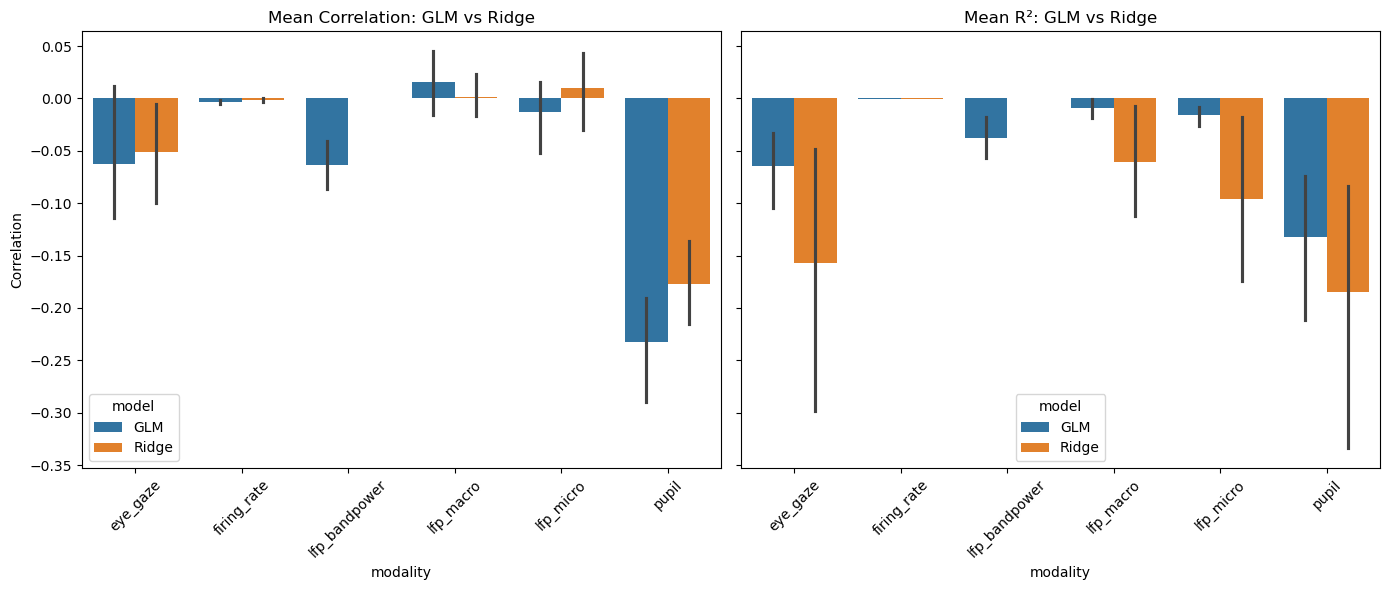

In [113]:
# Plot GLM vs Ridge comparison for correlations and R²

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_result_glm and df_result (Ridge) are available from previous cells
# Group by modality and model_name
glm_means = df_result_glm.groupby(["modality", "model_name"])[["corr", "r2"]].mean().reset_index()
ridge_means = df_result.groupby(["modality", "model_name"])[["corr", "r2"]].mean().reset_index()

# Melt for plotting
glm_melt = glm_means.melt(id_vars=["modality", "model_name"], var_name="metric", value_name="value")
glm_melt["model"] = "GLM"
ridge_melt = ridge_means.melt(id_vars=["modality", "model_name"], var_name="metric", value_name="value")
ridge_melt["model"] = "Ridge"

combined = pd.concat([glm_melt, ridge_melt], ignore_index=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Correlation
sns.barplot(data=combined[combined["metric"] == "corr"], x="modality", y="value", hue="model", ax=axes[0])
axes[0].set_title("Mean Correlation: GLM vs Ridge")
axes[0].set_ylabel("Correlation")
axes[0].tick_params(axis='x', rotation=45)

# R²
sns.barplot(data=combined[combined["metric"] == "r2"], x="modality", y="value", hue="model", ax=axes[1])
axes[1].set_title("Mean R²: GLM vs Ridge")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

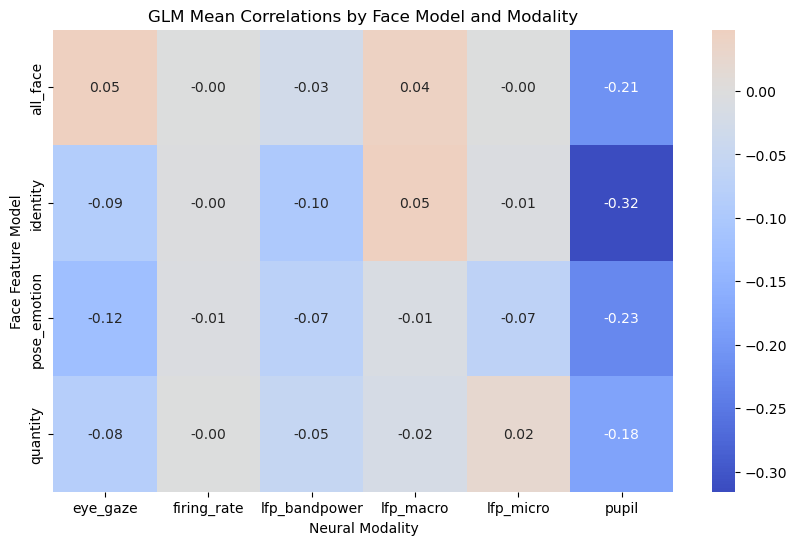

In [115]:
# Heatmap for GLM correlations

import seaborn as sns

# Pivot for heatmap
glm_pivot = glm_means.pivot(index="model_name", columns="modality", values="corr")

plt.figure(figsize=(10, 6))
sns.heatmap(glm_pivot, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("GLM Mean Correlations by Face Model and Modality")
plt.ylabel("Face Feature Model")
plt.xlabel("Neural Modality")
plt.show()

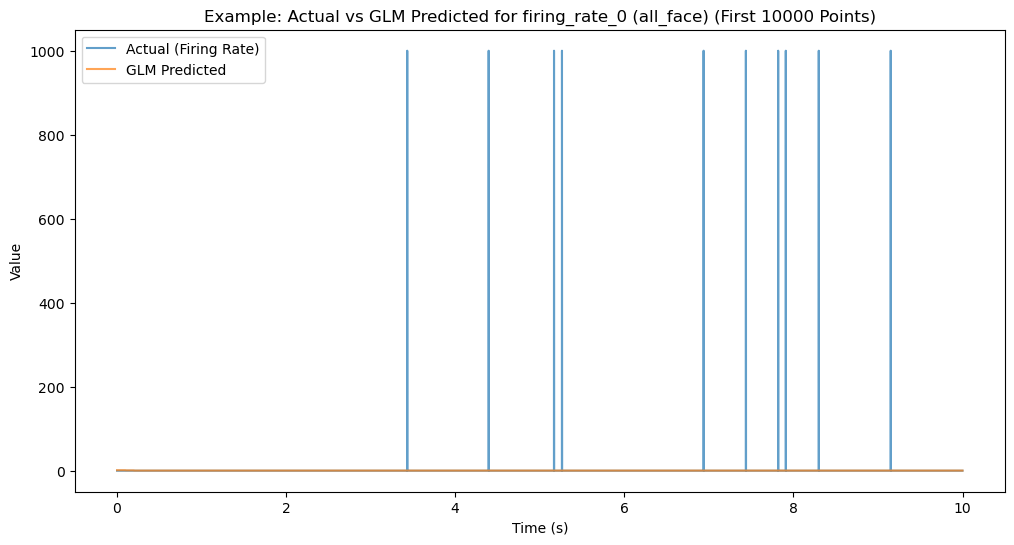

corr = -0.0074, r2 = -0.0003, alpha = 0.01, lags_sec = (0.0, 0.1, 0.2, 0.3)


In [116]:
# Modified GLM function to return predictions for plotting
import warnings
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

def glm_encoding_cv_single_output_with_preds(X, y, family=None, alpha=0.01, n_splits=5):
    """
    Gaussian-GLM encoding with CV predictions returned for plotting.
    Matches the regularized GLM approach used in the encoding analysis.
    """
    if family is None:
        family = sm.families.Gaussian()

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if X.ndim == 1:
        X = X[:, None]

    if len(X) != len(y):
        raise ValueError(f"X and y length mismatch: {len(X)} vs {len(y)}")

    valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    X = X[valid]
    y = y[valid]

    T = len(y)
    if T < n_splits:
        return {"corr": np.nan, "r2": np.nan, "pred": np.full(T, np.nan), "actual": y}

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full(T, np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr[:, None]).ravel()

        xtr = sm.add_constant(xtr, has_constant="add")
        xte = sm.add_constant(xte, has_constant="add")

        glm_model = sm.GLM(ytr_z, xtr, family=family)

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")

            if alpha > 0:
                # Do not penalize the intercept.
                alpha_vec = np.r_[0.0, np.full(xtr.shape[1] - 1, float(alpha))]
                try:
                    glm_result = glm_model.fit_regularized(
                        alpha=alpha_vec,
                        L1_wt=0.0,
                        maxiter=500,
                    )
                except Exception:
                    glm_result = glm_model.fit()
            else:
                glm_result = glm_model.fit()

        yhat_z = np.asarray(glm_result.predict(xte), dtype=float).reshape(-1)
        yhat = y_scaler.inverse_transform(yhat_z[:, None]).ravel()
        preds[te_idx] = yhat

    valid_pred = np.isfinite(preds)
    if valid_pred.sum() < 3:
        return {"corr": np.nan, "r2": np.nan, "pred": preds, "actual": y}

    yv = y[valid_pred]
    pv = preds[valid_pred]

    corr = np.corrcoef(yv, pv)[0, 1] if np.std(yv) > 0 and np.std(pv) > 0 else np.nan
    r2 = 1.0 - np.sum((yv - pv) ** 2) / np.sum((yv - np.mean(yv)) ** 2) if np.var(yv) > 0 else np.nan

    return {"corr": corr, "r2": r2, "pred": preds, "actual": y}


# Example plot
sample_modality = "firing_rate"
sample_model_name = "all_face"
sample_target_idx = 0
alpha = 0.01
lags_sec = (0.0, 0.1, 0.2, 0.3)   # define locally so this cell is self-contained

# Pick subject robustly
sub_key = sub if "sub" in globals() else next(iter(data))

# Get Y for the modality
Y_full = data[sub_key][sample_modality]
if isinstance(Y_full, dict):
    raise ValueError(f"{sample_modality} is dict-valued in this subject; choose a specific band first.")
else:
    Y = Y_full[:, sample_target_idx]

# Get X for the model
t_grid = np.asarray(data[sub_key]["time_grid"], dtype=float)
dt = float(np.median(np.diff(t_grid)))
lags = np.round(np.asarray(lags_sec) / dt).astype(int)

cols = face_feature_sets[sample_model_name]
df_face_grid = slicer.resample_face_df_to_timegrid(
    df_face_note,
    t_grid,
    cols,
    method_map=method_map,
)
X = df_face_grid[cols].astype(float).to_numpy()
X_lag = feature.make_lagged_matrix(X, lags)

# Run GLM for this specific target
res = glm_encoding_cv_single_output_with_preds(
    X_lag,
    Y,
    family=sm.families.Gaussian(),
    alpha=alpha,
    n_splits=5,
)
preds = res["pred"]
actual = res["actual"]

# Plot actual vs predicted for first 1000 points
n_plot = min(10000, len(t_grid), len(actual), len(preds))

plt.figure(figsize=(12, 6))
plt.plot(t_grid[:n_plot], actual[:n_plot], label="Actual (Firing Rate)", alpha=0.7)
plt.plot(t_grid[:n_plot], preds[:n_plot], label="GLM Predicted", alpha=0.7)
plt.title(
    f"Example: Actual vs GLM Predicted for "
    f"{sample_modality}_{sample_target_idx} ({sample_model_name}) "
    f"(First {n_plot} Points)"
)
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.legend()
plt.show()

print(f"corr = {res['corr']:.4f}, r2 = {res['r2']:.4f}, alpha = {alpha}, lags_sec = {lags_sec}")


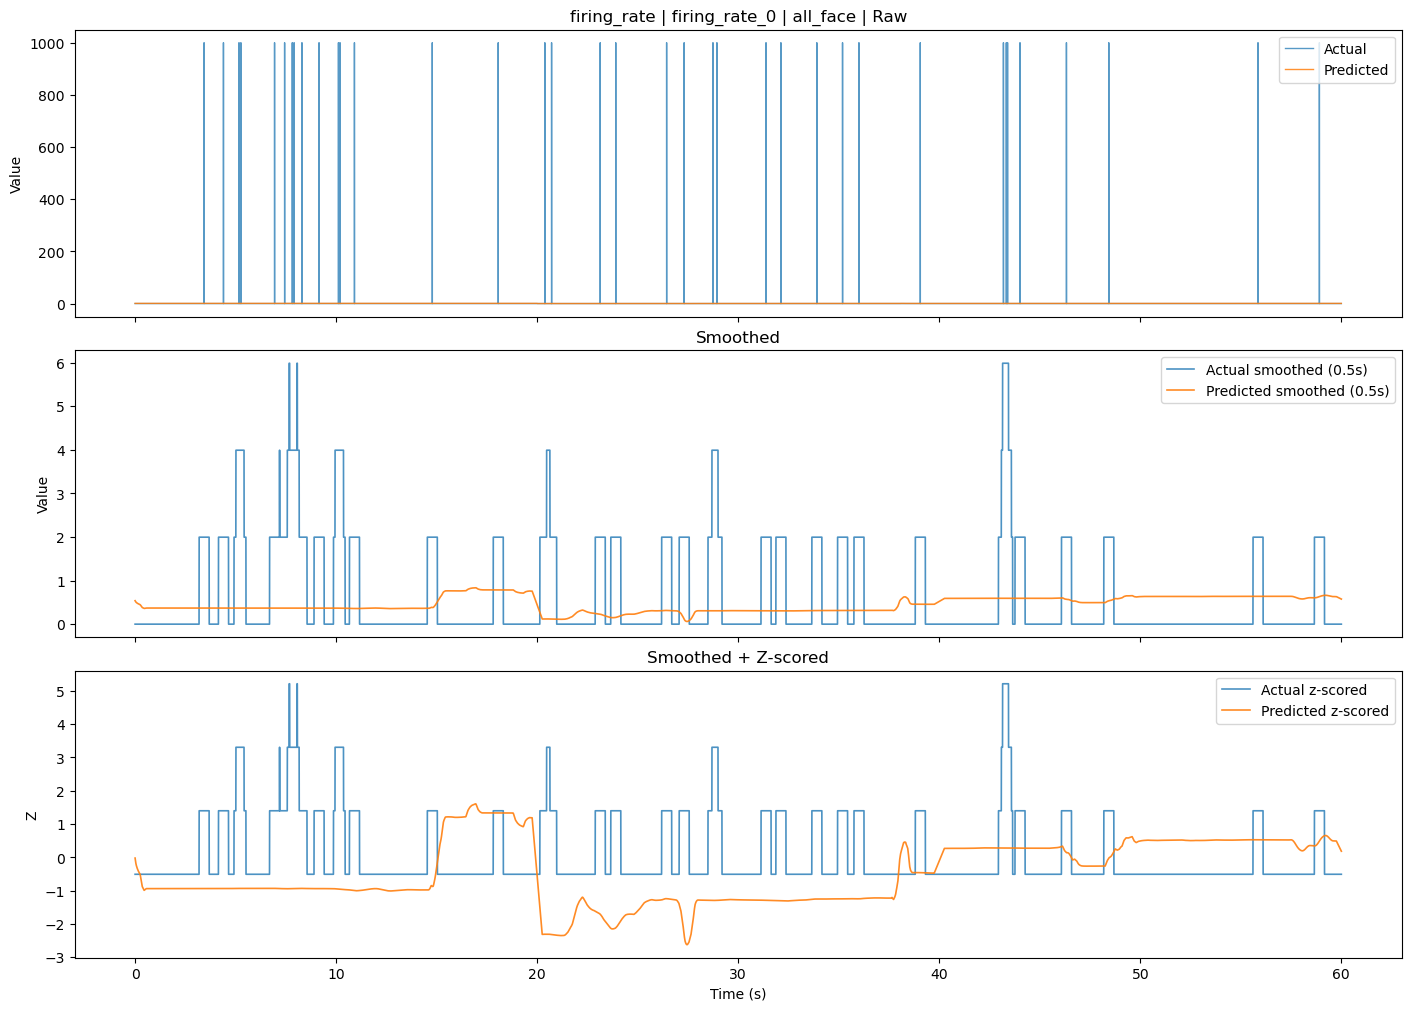

Subject: 41
Target: firing_rate_0
Face model: all_face
alpha=0.1, lags_sec=(0.0, 0.1, 0.2, 0.3), n_splits=5
corr=-0.0085, r2=-0.0002


In [117]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Settings
# -----------------------------
sample_modality = "firing_rate"   # e.g. firing_rate, lfp_macro, lfp_micro, pupil, eye_gaze
sample_model_name = "all_face"    # quantity, identity, pose_emotion, all_face
sample_target_idx = 0
alpha = 0.1
lags_sec = (0.0, 0.1, 0.2, 0.3)
n_splits = 5

# Plot controls
plot_start_sec = 0
plot_end_sec = 60                 # set to None for full recording
smooth_plot_sec = 0.50            # only for visualization, not model fitting

# Optional smoothing of discrete face regressors to match your newer setup
smooth_face_features = True
smooth_sec = 0.30
smooth_cols = [
    "Jacky_present",
    "any_front_face",
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised",
]

# -----------------------------
# Small helpers
# -----------------------------
def smooth_face_predictors(df_face_grid, cols_to_smooth, dt, smooth_sec=0.30):
    df_sm = df_face_grid.copy()

    if smooth_sec is None or smooth_sec <= 0:
        return df_sm

    win = max(1, int(round(float(smooth_sec) / float(dt))))
    if win % 2 == 0:
        win += 1

    binary_like = {
        "Jacky_present",
        "any_front_face",
        "emo_afraid",
        "emo_angry",
        "emo_happy",
        "emo_neutral",
        "emo_surprised",
    }

    for col in cols_to_smooth:
        if col not in df_sm.columns:
            continue

        x = pd.Series(df_sm[col].astype(float).to_numpy())
        x_sm = x.rolling(window=win, center=True, min_periods=1).mean().to_numpy()

        if col in binary_like:
            x_sm = np.clip(x_sm, 0.0, 1.0)
        elif col == "n_faces":
            x_sm = np.clip(x_sm, 0.0, None)

        df_sm[col] = x_sm

    return df_sm


def smooth_for_plot(x, dt, smooth_sec=0.50):
    x = np.asarray(x, dtype=float)
    if smooth_sec is None or smooth_sec <= 0:
        return x.copy()

    win = max(1, int(round(float(smooth_sec) / float(dt))))
    if win % 2 == 0:
        win += 1

    return (
        pd.Series(x)
        .rolling(window=win, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )


def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd < 1e-12:
        return np.full_like(x, np.nan)
    return (x - mu) / sd


def glm_encoding_cv_single_output_with_preds(X, y, family=None, alpha=0.1, n_splits=5):
    if family is None:
        family = sm.families.Gaussian()

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if X.ndim == 1:
        X = X[:, None]

    if len(X) != len(y):
        raise ValueError(f"X and y length mismatch: {len(X)} vs {len(y)}")

    valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    X = X[valid]
    y = y[valid]

    T = len(y)
    if T < n_splits:
        return {"corr": np.nan, "r2": np.nan, "pred": np.full(T, np.nan), "actual": y}

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full(T, np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr[:, None]).ravel()

        xtr = sm.add_constant(xtr, has_constant="add")
        xte = sm.add_constant(xte, has_constant="add")

        glm_model = sm.GLM(ytr_z, xtr, family=family)

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")

            if alpha > 0:
                alpha_vec = np.r_[0.0, np.full(xtr.shape[1] - 1, float(alpha))]
                try:
                    glm_result = glm_model.fit_regularized(
                        alpha=alpha_vec,
                        L1_wt=0.0,
                        maxiter=500,
                    )
                except Exception:
                    glm_result = glm_model.fit()
            else:
                glm_result = glm_model.fit()

        yhat_z = np.asarray(glm_result.predict(xte), dtype=float).reshape(-1)
        yhat = y_scaler.inverse_transform(yhat_z[:, None]).ravel()
        preds[te_idx] = yhat

    valid_pred = np.isfinite(preds)
    if valid_pred.sum() < 3:
        return {"corr": np.nan, "r2": np.nan, "pred": preds, "actual": y}

    yv = y[valid_pred]
    pv = preds[valid_pred]

    corr = np.corrcoef(yv, pv)[0, 1] if np.std(yv) > 0 and np.std(pv) > 0 else np.nan
    r2 = 1.0 - np.sum((yv - pv) ** 2) / np.sum((yv - np.mean(yv)) ** 2) if np.var(yv) > 0 else np.nan

    return {"corr": corr, "r2": r2, "pred": preds, "actual": y}


# -----------------------------
# Build X and Y
# -----------------------------
sub_key = sub if "sub" in globals() else next(iter(data))

t_grid = np.asarray(data[sub_key]["time_grid"], dtype=float)
dt = float(np.median(np.diff(t_grid)))
lags = np.round(np.asarray(lags_sec) / dt).astype(int)

Y_full = data[sub_key][sample_modality]
if isinstance(Y_full, dict):
    raise ValueError(
        f"{sample_modality} is dict-valued. Choose a specific band first "
        f"(e.g. extract one lfp_bandpower band before plotting)."
    )

Y2d, target_names = flatten_targets(Y_full, sample_modality)
if sample_target_idx >= Y2d.shape[1]:
    raise IndexError(
        f"sample_target_idx={sample_target_idx} out of range for "
        f"{sample_modality} with {Y2d.shape[1]} targets"
    )

y = Y2d[:, sample_target_idx]
target_name = target_names[sample_target_idx]

cols = face_feature_sets[sample_model_name]

df_face_grid = slicer.resample_face_df_to_timegrid(
    df_face_note,
    t_grid,
    cols,
    method_map=method_map,
)

if smooth_face_features:
    df_face_grid = smooth_face_predictors(
        df_face_grid=df_face_grid,
        cols_to_smooth=smooth_cols,
        dt=dt,
        smooth_sec=smooth_sec,
    )

X = df_face_grid[cols].astype(float).to_numpy()
X_lag = feature.make_lagged_matrix(X, lags)

# -----------------------------
# Fit + predict
# -----------------------------
res = glm_encoding_cv_single_output_with_preds(
    X=X_lag,
    y=y,
    family=sm.families.Gaussian(),
    alpha=alpha,
    n_splits=n_splits,
)

actual = res["actual"]
preds = res["pred"]

actual_sm = smooth_for_plot(actual, dt=dt, smooth_sec=smooth_plot_sec)
preds_sm = smooth_for_plot(preds, dt=dt, smooth_sec=smooth_plot_sec)

actual_z = zscore_safe(actual_sm)
preds_z = zscore_safe(preds_sm)

# -----------------------------
# Choose plot window
# -----------------------------
if plot_end_sec is None:
    mask = np.ones_like(t_grid, dtype=bool)
else:
    mask = (t_grid >= plot_start_sec) & (t_grid <= plot_end_sec)

t_plot = t_grid[mask]
actual_plot = actual[mask]
preds_plot = preds[mask]
actual_sm_plot = actual_sm[mask]
preds_sm_plot = preds_sm[mask]
actual_z_plot = actual_z[mask]
preds_z_plot = preds_z[mask]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

axes[0].plot(t_plot, actual_plot, label="Actual", alpha=0.75, linewidth=1.0)
axes[0].plot(t_plot, preds_plot, label="Predicted", alpha=0.85, linewidth=1.0)
axes[0].set_title(f"{sample_modality} | {target_name} | {sample_model_name} | Raw")
axes[0].set_ylabel("Value")
axes[0].legend(loc="upper right")

axes[1].plot(t_plot, actual_sm_plot, label=f"Actual smoothed ({smooth_plot_sec}s)", alpha=0.8, linewidth=1.2)
axes[1].plot(t_plot, preds_sm_plot, label=f"Predicted smoothed ({smooth_plot_sec}s)", alpha=0.9, linewidth=1.2)
axes[1].set_title("Smoothed")
axes[1].set_ylabel("Value")
axes[1].legend(loc="upper right")

axes[2].plot(t_plot, actual_z_plot, label="Actual z-scored", alpha=0.8, linewidth=1.2)
axes[2].plot(t_plot, preds_z_plot, label="Predicted z-scored", alpha=0.9, linewidth=1.2)
axes[2].set_title("Smoothed + Z-scored")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Z")
axes[2].legend(loc="upper right")

plt.show()

print(f"Subject: {sub_key}")
print(f"Target: {target_name}")
print(f"Face model: {sample_model_name}")
print(f"alpha={alpha}, lags_sec={lags_sec}, n_splits={n_splits}")
print(f"corr={res['corr']:.4f}, r2={res['r2']:.4f}")
